# FractalRecall Prototyping — Notebook 1: Model Selection & Embedding Baseline

> **Project:** FractalRecall — Hierarchical context-aware embedding retrieval
> **Question this notebook answers:** How well does standard RAG (no enrichment) perform on the Aethelgard corpus, and which embedding model should be the primary model for subsequent notebooks?
> **Corpus:** Aethelgard worldbuilding (Markdown + YAML frontmatter)
> **Embedding model:** `nomic-embed-text-v2-moe` via sentence-transformers
> **Vector DB:** ChromaDB (in-memory)
> **Metrics:** Precision@5, Recall@10, NDCG@10, MRR
> **Full context for AI assistants:** See `COLAB-SESSION-CONTEXT.md` in this directory

## What is FractalRecall?

FractalRecall tests the hypothesis that embedding retrieval improves when text chunks are enriched with **hierarchical structural context** before embedding. Each chunk carries up to 8 "context layers" (Corpus → Domain → Entity → Authority → Temporal → Relational → Section → Content) prepended as natural language prefixes. The enriched text is embedded as a single vector.

## Notebook Sequence

| # | Notebook | Status |
|

---

## Scope Expansion (R-01 Discovery)

**Note:** Research note R-01 identified that nomic-embed-text-v2-moe has a 512-token context window, not the previously assumed 8,192 tokens. This discovery expands the notebook's scope from a two-model comparison to a three-model comparison, allowing us to empirically evaluate the trade-off between narrower context windows and mixture-of-experts architecture against standard transformer approaches.

This notebook now compares three embedding models:

- **nomic-embed-text-v2-moe:** 512-token context window, MoE architecture (475M/305M parameters)
- **nomic-embed-text-v1.5:** 8,192-token context window, standard transformer
- **BAAI/bge-m3:** 8,192-token context window, dense + sparse + ColBERT hybrid retrieval


In [ ]:
# Install all required dependencies for D-21: Model Selection & Embedding Baseline
# These packages cover embedding models, retrieval infrastructure, data processing, and visualization

import subprocess
import sys

packages = [
    "sentence-transformers>=3.0.0",      # Primary embedding model loader (v2-moe, v1.5)
    "chromadb>=1.0.0",                   # Vector database for retrieval evaluation
    "pyyaml>=6.0",                       # YAML parsing for corpus frontmatter
    "numpy>=1.24.0",                     # Numerical operations for embeddings
    "scipy>=1.10.0",                     # Scientific computing for distance metrics
    "scikit-learn>=1.3.0",               # Metrics (precision, recall, NDCG) and clustering
    "matplotlib>=3.7.0",                 # Plotting evaluation results
    "seaborn>=0.12.0",                   # Statistical visualization
    "umap-learn>=0.5.0",                 # Dimensionality reduction for embedding visualization
    "pandas>=2.0.0",                     # Data frames for results aggregation
    "tqdm>=4.65.0",                      # Progress bars for corpus loading
    "transformers>=4.30.0",              # Tokenizer utilities and model infrastructure
    "FlagEmbedding>=1.2.0",              # BGE-m3 model loader (alternative to sentence-transformers)
    "tabulate>=0.9.0",                    # Table formatting for results display
]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

print("✓ All dependencies installed successfully")


✓ All dependencies installed successfully


In [ ]:
!pip install transformers==4.47.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 96.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.0
    Uninstalling huggingface_hub-1.4.0:
      Successfully uninstalled huggingface_hub-1.4.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
"""
Imports and Configuration for D-21: Model Selection & Embedding Baseline

This cell centralizes all imports and defines the ModelConfig dataclass that
encapsulates per-model configuration for chunking, embedding, and inference.
Reference: D-20 §6 for field mapping strategy; R-02 for embedding model selection.
"""

import os
import json
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Tuple, Optional, Literal
import logging

import numpy as np
import pandas as pd
import yaml
from tqdm import tqdm

# Embedding model loaders
from sentence_transformers import SentenceTransformer
from FlagEmbedding import FlagModel

# Retrieval and evaluation
import chromadb
from chromadb.config import Settings

# Metrics and analysis
from sklearn.metrics import (
    precision_score, recall_score, ndcg_score,
    accuracy_score
)

def mean_reciprocal_rank(relevant, ranked_results):
    """Compute MRR: 1/rank of the first relevant result."""
    for i, result in enumerate(ranked_results, 1):
        if result in relevant:
            return 1.0 / i
    return 0.0
from scipy.spatial.distance import cosine

# Visualization (optional, imported for reference)
import matplotlib.pyplot as plt
import seaborn as sns
import umap

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

@dataclass
class ModelConfig:
    """
    Configuration for a single embedding model.

    This dataclass encapsulates all per-model parameters needed for:
    1. Document chunking (context window constraints)
    2. Model loading (inference framework)
    3. Embedding generation (prefixes, dimensions)

    Reference: D-20 §2 discusses chunking strategy; R-03 covers embedding model properties.

    Attributes:
        name: Human-readable identifier (e.g., "v2-moe")
        model_id: HuggingFace model path (e.g., "nomic-ai/nomic-embed-text-v2-moe")
        context_window: Maximum tokens the model can process in one pass
        target_chunk_tokens: Ideal chunk size for optimal retrieval (semantic sweet spot)
        max_chunk_tokens: Hard upper limit enforced during chunking (respect context window)
        min_chunk_tokens: Minimum chunk size to preserve meaningful context
        overlap_tokens: Sliding window overlap to maintain semantic continuity across chunks
        embedding_dim: Output embedding dimensionality from the model
        loader: Which framework loads this model ("sentence_transformers" or "flag_embedding")
        doc_prefix: Prefix text prepended to documents (if any) before embedding
        query_prefix: Prefix text prepended to queries (if any) before embedding
    """
    name: str
    model_id: str
    context_window: int
    target_chunk_tokens: int
    max_chunk_tokens: int
    min_chunk_tokens: int
    overlap_tokens: int
    embedding_dim: int
    loader: Literal["sentence_transformers", "flag_embedding"]
    doc_prefix: str = ""
    query_prefix: str = ""

    def to_dict(self) -> Dict:
        """Convert to dictionary, excluding computed fields."""
        return asdict(self)

# Model Registry: Three models representing different architecture/window trade-offs
# Reference: R-01 discovered v2-moe has 512-token window (not 8,192 as initially assumed)

MODELS: Dict[str, ModelConfig] = {
    "v2-moe": ModelConfig(
        name="nomic-embed-text-v2-moe",
        model_id="nomic-ai/nomic-embed-text-v2-moe",
        context_window=512,
        target_chunk_tokens=350,      # Aim for 350-token chunks (68% of window)
        max_chunk_tokens=450,         # Hard ceiling respecting 512-token constraint
        min_chunk_tokens=128,         # Minimum for semantic coherence
        overlap_tokens=96,            # 27% overlap for continuity
        embedding_dim=768,
        loader="sentence_transformers",
        doc_prefix="search_document",  # Model-specific prefix per nomic docs
        query_prefix="search_query",
    ),
    "v1.5": ModelConfig(
        name="nomic-embed-text-v1.5",
        model_id="nomic-ai/nomic-embed-text-v1.5",
        context_window=8192,
        target_chunk_tokens=600,      # Larger chunks possible with 8k window
        max_chunk_tokens=1024,
        min_chunk_tokens=128,
        overlap_tokens=150,           # 25% overlap
        embedding_dim=768,
        loader="sentence_transformers",
        doc_prefix="search_document",
        query_prefix="search_query",
    ),
    "bge-m3": ModelConfig(
        name="BAAI/bge-m3",
        model_id="BAAI/bge-m3",
        context_window=8192,
        target_chunk_tokens=600,
        max_chunk_tokens=1024,
        min_chunk_tokens=128,
        overlap_tokens=150,
        embedding_dim=1024,           # Larger embeddings than nomic models
        loader="flag_embedding",      # Requires FlagEmbedding loader
        doc_prefix="",                # BGE-m3 does not use explicit prefixes
        query_prefix="",
    ),
}

# Evaluation Constants (Reference: D-20 §8 for metric definitions)
K_PRECISION = 5      # Precision@5: fraction of top 5 results that are relevant
K_RECALL = 10        # Recall@10: fraction of relevant docs found in top 10
K_NDCG = 10          # NDCG@10: normalized discounted cumulative gain at 10

# File system paths
CORPUS_DIR = Path("./test-corpus")           # Input: Aethelgard corpus markdown files
OUTPUT_DIR = Path("./d21-output")            # Output: evaluation results and embeddings

# Ensure output directory exists
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

logger.info(f"Configuration loaded: {len(MODELS)} models registered")
logger.info(f"Corpus directory: {CORPUS_DIR}")
logger.info(f"Output directory: {OUTPUT_DIR}")


In [ ]:
"""
Ground-Truth Query Set for D-21 Evaluation

This cell defines 36 queries covering five categories:
- SINGLE_HOP (11): Direct attribute lookups
- MULTI_HOP (8): Cross-entity relationship traversal
- AUTHORITY (5): Canonical vs. draft vs. superseded status questions
- TEMPORAL (6): Time-based historical queries
- EXPLORATORY (6): Open-ended relationship discovery

Each query has expected results annotated with relevance scores (1-3).
Reference: D-20 §7 for query type taxonomy; R-02 for Aethelgard corpus structure.
"""

from dataclasses import dataclass

@dataclass
class GroundTruthQuery:
    """
    A single ground-truth query with expected relevant documents.

    Attributes:
        id: Query identifier (e.g., "Q-01")
        type: Category: SINGLE_HOP, MULTI_HOP, AUTHORITY, TEMPORAL, or EXPLORATORY
        text: The query text as a natural language question
        expected: List of (filename, relevance_score) tuples where:
                  - relevance_score 3 = highly relevant (must appear)
                  - relevance_score 2 = somewhat relevant (should appear)
                  - relevance_score 1 = tangentially relevant (optional)
    """
    id: str
    type: str
    text: str
    expected: List[Tuple[str, int]]

# SINGLE_HOP QUERIES (11 total)
# These test direct lookups of facts, entities, and concepts

QUERIES: Dict[str, GroundTruthQuery] = {
    "Q-01": GroundTruthQuery(
        id="Q-01",
        type="SINGLE_HOP",
        text="What is the Echo-Cant communication system?",
        expected=[
            ("000-codex_echo-cant.md", 3),
            ("000-resources_comprehensive-glossary.md", 2),
        ]
    ),
    "Q-02": GroundTruthQuery(
        id="Q-02",
        type="SINGLE_HOP",
        text="What are the defining characteristics of the Void-Marked?",
        expected=[
            ("db02-wb_void-marked-assembled-entry.md", 3),
            ("db03-dc_jotun-reader-chronology.md", 2),
        ]
    ),
    "Q-03": GroundTruthQuery(
        id="Q-03",
        type="SINGLE_HOP",
        text="Describe the Harrow-Sick condition and its effects.",
        expected=[
            ("000-codex_harrow-sick.md", 3),
            ("db02-wb_medical-phenomena-entry.md", 2),
        ]
    ),
    "Q-04": GroundTruthQuery(
        id="Q-04",
        type="SINGLE_HOP",
        text="What is the ODIN Protocol?",
        expected=[
            ("000-codex_odin-protocol.md", 3),
            ("standalone_aether-weave-os.md", 2),
            ("standalone_nine-tiers-architecture.md", 2),
        ]
    ),
    "Q-05": GroundTruthQuery(
        id="Q-05",
        type="SINGLE_HOP",
        text="What is the Æther-Weave operating system?",
        expected=[
            ("standalone_aether-weave-os.md", 3),
            ("000-resources_comprehensive-glossary.md", 2),
        ]
    ),
    "Q-06": GroundTruthQuery(
        id="Q-06",
        type="SINGLE_HOP",
        text="Who are the Scavenger-Barons and what do they do?",
        expected=[
            ("db02-wb_scavenger-barons-assembled-entry.md", 3),
            ("db03-dc_contract-dispute-case-study.md", 2),
        ]
    ),
    "Q-07": GroundTruthQuery(
        id="Q-07",
        type="SINGLE_HOP",
        text="What is the Nine-Tiers architectural framework?",
        expected=[
            ("standalone_nine-tiers-architecture.md", 3),
            ("000-resources_comprehensive-glossary.md", 2),
        ]
    ),
    "Q-27": GroundTruthQuery(
        id="Q-27",
        type="SINGLE_HOP",
        text="What are the primary functions of the Warden-Host?",
        expected=[
            ("db02-wb_warden-host-assembled-entry.md", 3),
            ("db03-dc_sanctuary-establishment-record.md", 2),
        ]
    ),
    "Q-28": GroundTruthQuery(
        id="Q-28",
        type="SINGLE_HOP",
        text="Define the Glitch in the context of Aethelgard's history.",
        expected=[
            ("000-resources_comprehensive-glossary.md", 3),
            ("standalone_nine-tiers-architecture.md", 2),
        ]
    ),
    "Q-30": GroundTruthQuery(
        id="Q-30",
        type="SINGLE_HOP",
        text="What is the Spell-Lock system?",
        expected=[
            ("000-codex_spell-lock.md", 3),
            ("standalone_aether-weave-os.md", 2),
        ]
    ),
    "Q-34": GroundTruthQuery(
        id="Q-34",
        type="SINGLE_HOP",
        text="Describe the Weir-Bone material and its properties.",
        expected=[
            ("db02-wb_weir-bone-assembled-entry.md", 3),
            ("000-resources_comprehensive-glossary.md", 2),
        ]
    ),
}

# MULTI_HOP QUERIES (8 total)
# These require traversing relationships between multiple entities/concepts

QUERIES.update({
    "Q-08": GroundTruthQuery(
        id="Q-08",
        type="MULTI_HOP",
        text="How do Iron-Bane and God-Sleeper theological positions on Svin-fylking differ?",
        expected=[
            ("db03-dc_iron-bane-theological-analysis.md", 3),
            ("db03-dc_god-sleeper-operational-doctrine.md", 3),
            ("db02-wb_svin-fylking-assembled-entry.md", 2),
        ]
    ),
    "Q-09": GroundTruthQuery(
        id="Q-09",
        type="MULTI_HOP",
        text="What is the relationship between the Harrow-Sick and the Void-Marked?",
        expected=[
            ("000-codex_harrow-sick.md", 3),
            ("db02-wb_void-marked-assembled-entry.md", 3),
            ("db03-dc_medical-causality-research.md", 2),
        ]
    ),
    "Q-10": GroundTruthQuery(
        id="Q-10",
        type="MULTI_HOP",
        text="How do the Scavenger-Barons use Spell-Lock in their operations?",
        expected=[
            ("db02-wb_scavenger-barons-assembled-entry.md", 3),
            ("000-codex_spell-lock.md", 3),
            ("db03-dc_contract-dispute-case-study.md", 2),
        ]
    ),
    "Q-11": GroundTruthQuery(
        id="Q-11",
        type="MULTI_HOP",
        text="Explain the conflict between Warden-Host sanctuary protocols and Iron-Bane territorial claims.",
        expected=[
            ("db02-wb_warden-host-assembled-entry.md", 3),
            ("db03-dc_iron-bane-theological-analysis.md", 3),
            ("db03-dc_sanctuary-establishment-record.md", 2),
        ]
    ),
    "Q-12": GroundTruthQuery(
        id="Q-12",
        type="MULTI_HOP",
        text="How does the ODIN Protocol interact with the Æther-Weave OS?",
        expected=[
            ("000-codex_odin-protocol.md", 3),
            ("standalone_aether-weave-os.md", 3),
            ("standalone_nine-tiers-architecture.md", 2),
        ]
    ),
    "Q-29": GroundTruthQuery(
        id="Q-29",
        type="MULTI_HOP",
        text="What role does the Echo-Cant system play in maintaining Warden-Host operations?",
        expected=[
            ("000-codex_echo-cant.md", 3),
            ("db02-wb_warden-host-assembled-entry.md", 3),
            ("db03-dc_sanctuary-establishment-record.md", 2),
        ]
    ),
    "Q-31": GroundTruthQuery(
        id="Q-31",
        type="MULTI_HOP",
        text="How do Void-Marked and Weir-Bone materials interact in salvage contexts?",
        expected=[
            ("db02-wb_void-marked-assembled-entry.md", 3),
            ("db02-wb_weir-bone-assembled-entry.md", 3),
            ("db03-dc_salvage-operations-manual.md", 2),
        ]
    ),
    "Q-35": GroundTruthQuery(
        id="Q-35",
        type="MULTI_HOP",
        text="What is the relationship between the Nine-Tiers architecture and Svin-fylking religious doctrine?",
        expected=[
            ("standalone_nine-tiers-architecture.md", 3),
            ("db02-wb_svin-fylking-assembled-entry.md", 3),
            ("db03-dc_god-sleeper-operational-doctrine.md", 2),
        ]
    ),
})

# AUTHORITY QUERIES (5 total)
# These test knowledge of canonical vs. draft vs. superseded information

QUERIES.update({
    "Q-13": GroundTruthQuery(
        id="Q-13",
        type="AUTHORITY",
        text="What is the canonical explanation for how the Glitch occurred?",
        expected=[
            ("000-resources_comprehensive-glossary.md", 3),
            ("standalone_nine-tiers-architecture.md", 2),
        ]
    ),
    "Q-14": GroundTruthQuery(
        id="Q-14",
        type="AUTHORITY",
        text="What are the established facts about the God-Sleeper movement origins?",
        expected=[
            ("db03-dc_god-sleeper-operational-doctrine.md", 3),
            ("db03-dc_historical-theological-survey.md", 2),
        ]
    ),
    "Q-15": GroundTruthQuery(
        id="Q-15",
        type="AUTHORITY",
        text="Which interpretations of Harrow-Sick etiology are considered canon?",
        expected=[
            ("000-codex_harrow-sick.md", 3),
            ("db03-dc_medical-causality-research.md", 2),
        ]
    ),
    "Q-16": GroundTruthQuery(
        id="Q-16",
        type="AUTHORITY",
        text="What is the official Warden-Host stance on Void-Marked rights?",
        expected=[
            ("db02-wb_warden-host-assembled-entry.md", 3),
            ("db02-wb_void-marked-assembled-entry.md", 2),
            ("db03-dc_sanctuary-establishment-record.md", 2),
        ]
    ),
    "Q-17": GroundTruthQuery(
        id="Q-17",
        type="AUTHORITY",
        text="According to published sources, what materials constitute a valid Spell-Lock?",
        expected=[
            ("000-codex_spell-lock.md", 3),
            ("000-resources_comprehensive-glossary.md", 2),
        ]
    ),
})

# TEMPORAL QUERIES (6 total)
# These test time-based historical retrieval across the Aethelgard timeline

QUERIES.update({
    "Q-18": GroundTruthQuery(
        id="Q-18",
        type="TEMPORAL",
        text="What major events happened in the first century after the Glitch (Year 0-100 PG)?",
        expected=[
            ("db03-dc_jotun-reader-chronology.md", 3),
            ("db03-dc_sanctuary-establishment-record.md", 2),
        ]
    ),
    "Q-19": GroundTruthQuery(
        id="Q-19",
        type="TEMPORAL",
        text="When was the Warden-Host sanctuary established and what precipitated it?",
        expected=[
            ("db03-dc_sanctuary-establishment-record.md", 3),
            ("db02-wb_warden-host-assembled-entry.md", 2),
        ]
    ),
    "Q-20": GroundTruthQuery(
        id="Q-20",
        type="TEMPORAL",
        text="Trace the chronological development of Iron-Bane theological doctrine.",
        expected=[
            ("db03-dc_iron-bane-theological-analysis.md", 3),
            ("db03-dc_historical-theological-survey.md", 2),
        ]
    ),
    "Q-21": GroundTruthQuery(
        id="Q-21",
        type="TEMPORAL",
        text="What is the timeline of major salvage discoveries in the Aethelgard region?",
        expected=[
            ("db03-dc_salvage-operations-manual.md", 3),
            ("db03-dc_jotun-reader-chronology.md", 2),
        ]
    ),
    "Q-22": GroundTruthQuery(
        id="Q-22",
        type="TEMPORAL",
        text="When did the God-Sleeper movement gain significant political influence?",
        expected=[
            ("db03-dc_god-sleeper-operational-doctrine.md", 3),
            ("db03-dc_historical-theological-survey.md", 2),
        ]
    ),
    "Q-23": GroundTruthQuery(
        id="Q-23",
        type="TEMPORAL",
        text="Describe the sequence of events in the Scavenger-Baron contract dispute.",
        expected=[
            ("db03-dc_contract-dispute-case-study.md", 3),
            ("db02-wb_scavenger-barons-assembled-entry.md", 2),
        ]
    ),
})

# EXPLORATORY QUERIES (6 total)
# These test open-ended discovery of related concepts and themes

QUERIES.update({
    "Q-24": GroundTruthQuery(
        id="Q-24",
        type="EXPLORATORY",
        text="What are the major political tensions in post-Glitch Aethelgard?",
        expected=[
            ("db03-dc_iron-bane-theological-analysis.md", 3),
            ("db03-dc_god-sleeper-operational-doctrine.md", 3),
            ("db03-dc_contract-dispute-case-study.md", 2),
            ("db02-wb_scavenger-barons-assembled-entry.md", 2),
        ]
    ),
    "Q-25": GroundTruthQuery(
        id="Q-25",
        type="EXPLORATORY",
        text="How do different factions view the technological salvage efforts?",
        expected=[
            ("db02-wb_scavenger-barons-assembled-entry.md", 3),
            ("db03-dc_salvage-operations-manual.md", 3),
            ("db03-dc_iron-bane-theological-analysis.md", 2),
            ("db03-dc_god-sleeper-operational-doctrine.md", 2),
        ]
    ),
    "Q-26": GroundTruthQuery(
        id="Q-26",
        type="EXPLORATORY",
        text="What medical and physiological mysteries remain unsolved in Aethelgard?",
        expected=[
            ("000-codex_harrow-sick.md", 3),
            ("db03-dc_medical-causality-research.md", 3),
            ("db02-wb_void-marked-assembled-entry.md", 2),
        ]
    ),
    "Q-32": GroundTruthQuery(
        id="Q-32",
        type="EXPLORATORY",
        text="What are the intersections between religious doctrine and technological systems in Aethelgard?",
        expected=[
            ("standalone_nine-tiers-architecture.md", 3),
            ("db02-wb_svin-fylking-assembled-entry.md", 3),
            ("000-codex_odin-protocol.md", 2),
            ("db03-dc_historical-theological-survey.md", 2),
        ]
    ),
    "Q-33": GroundTruthQuery(
        id="Q-33",
        type="EXPLORATORY",
        text="How do material properties (Weir-Bone, Void-Marked) influence cultural practices?",
        expected=[
            ("db02-wb_weir-bone-assembled-entry.md", 3),
            ("db02-wb_void-marked-assembled-entry.md", 3),
            ("db02-wb_warden-host-assembled-entry.md", 2),
        ]
    ),
    "Q-36": GroundTruthQuery(
        id="Q-36",
        type="EXPLORATORY",
        text="What gaps exist in the documented understanding of Aethelgard's pre-Glitch history?",
        expected=[
            ("db03-dc_historical-theological-survey.md", 3),
            ("db03-dc_jotun-reader-chronology.md", 3),
            ("000-resources_comprehensive-glossary.md", 2),
        ]
    ),
})

# Validation: Ensure exactly 36 queries are defined (11+8+5+6+6 = 36)
query_type_counts = {}
for query in QUERIES.values():
    query_type_counts[query.type] = query_type_counts.get(query.type, 0) + 1

logger.info(f"Ground-truth query set loaded: {len(QUERIES)} queries")
logger.info(f"Query type distribution: {query_type_counts}")

assert len(QUERIES) == 36, f"Expected 36 queries, got {len(QUERIES)}"
assert query_type_counts.get("SINGLE_HOP", 0) == 11, f"Expected 11 SINGLE_HOP, got {query_type_counts.get('SINGLE_HOP', 0)}"
assert query_type_counts.get("MULTI_HOP", 0) == 8, f"Expected 8 MULTI_HOP, got {query_type_counts.get('MULTI_HOP', 0)}"
assert query_type_counts.get("AUTHORITY", 0) == 5, f"Expected 5 AUTHORITY, got {query_type_counts.get('AUTHORITY', 0)}"
assert query_type_counts.get("TEMPORAL", 0) == 6, f"Expected 6 TEMPORAL, got {query_type_counts.get('TEMPORAL', 0)}"
assert query_type_counts.get("EXPLORATORY", 0) == 6, f"Expected 6 EXPLORATORY, got {query_type_counts.get('EXPLORATORY', 0)}"

print("✓ All 36 ground-truth queries validated")


✓ All 36 ground-truth queries validated


In [ ]:
"""
Field Mapping and Normalization Pipeline (D-20 §6 Strategy)

This cell defines the normalization pipeline that:
1. Maps free-form source field names to canonical internal names
2. Standardizes value formats (enums, booleans, etc.)
3. Validates and enriches metadata

The goal is to create a unified metadata representation across diverse
corpus document formats.

Reference: D-20 §6 for normalization strategy; R-02 for field catalog.
"""

from typing import Any, Dict, Optional
from enum import Enum

class AuthorityLayer(str, Enum):
    """
    Three-tier classification for claim authority.

    - L1_MYTHOLOGICAL: Foundational lore accepted across all factions
    - L2_DIAGNOSTIC: Standard technical/operational documentation
    - L3_TECHNICAL: Specialized implementations or faction-specific claims
    """
    L1_MYTHOLOGICAL = "L1-Mythological"
    L2_DIAGNOSTIC = "L2-Diagnostic"
    L3_TECHNICAL = "L3-Technical"

class CanonStatus(str, Enum):
    """Canon status of a document."""
    CANONICAL = "Canonical"
    DRAFT = "Draft"
    PUBLISHED = "Published"
    DONE = "Done"
    SUPERSEDED = "Superseded"
    DEPRECATED = "Deprecated"

class EntityType(str, Enum):
    """Broad entity type categories (normalized from 38 free-form types)."""
    ENTITY = "entity"
    FACTION = "faction"
    DOCUMENT = "document"
    EVENT = "event"
    SYSTEM = "system"
    TERM = "term"

# Field Mapping Dictionary
# Maps source corpus field names to normalized internal names
FIELD_MAP = {
    # Title variants
    "title": "name",
    "Title": "name",
    "heading": "name",

    # Entity classification
    "entity_type": "type",
    "Entity Type": "type",
    "type": "type",
    "entity_kind": "type",

    # Canon status
    "canon_status": "canon",
    "Canon Status": "canon",
    "status": "canon",
    "publication_status": "canon",

    # Authority/credibility layer
    "authority_layer": "authority_layer",
    "Authority Layer": "authority_layer",
    "layer": "authority_layer",

    # References and relationships
    "cross_references": "relationships",
    "Cross References": "relationships",
    "related_entities": "relationships",
    "relationships": "relationships",
    "references": "relationships",

    # Document metadata
    "source": "source",
    "author": "author",
    "created_date": "created_date",
    "modified_date": "modified_date",
    "version": "version",

    # Additional fields
    "tags": "tags",
    "keywords": "keywords",
}

def normalize_canon_status(value: Optional[str]) -> Optional[str]:
    """
    Normalize canon status values to canonical form.

    Maps various textual representations to standard status values:
    - "Canonical", "Published", "Done", "DONE" -> "Canonical"
    - "Draft", "DRAFT" -> "Draft"
    - "SUPERSEDED" -> "Superseded"

    Args:
        value: Raw status string from frontmatter

    Returns:
        Normalized status string, or None if value is None/unrecognized
    """
    if value is None:
        return None

    value_normalized = value.strip().lower()

    if value_normalized in ("canonical", "published", "done"):
        return CanonStatus.CANONICAL.value
    elif value_normalized == "draft":
        return CanonStatus.DRAFT.value
    elif value_normalized == "superseded":
        return CanonStatus.SUPERSEDED.value
    else:
        # Log unrecognized values but return as-is
        logger.warning(f"Unrecognized canon status: {value}")
        return value

def normalize_authority_layer(value: Optional[str]) -> str:
    """
    Normalize authority layer designation.

    Maps various representations to three-tier system:
    - "L1*", "Mythological" -> L1-Mythological
    - "L2*", "Diagnostic", or unrecognized -> L2-Diagnostic (default)
    - "L3*", "Technical" -> L3-Technical

    Default to L2 if unrecognized (most documents are diagnostic).

    Args:
        value: Raw authority layer string

    Returns:
        Normalized authority layer string
    """
    if value is None:
        return AuthorityLayer.L2_DIAGNOSTIC.value

    value_normalized = value.strip().lower()

    if "l1" in value_normalized or "mythological" in value_normalized:
        return AuthorityLayer.L1_MYTHOLOGICAL.value
    elif "l3" in value_normalized or "technical" in value_normalized:
        return AuthorityLayer.L3_TECHNICAL.value
    else:
        # Default to L2 (diagnostic)
        return AuthorityLayer.L2_DIAGNOSTIC.value

def normalize_entity_type(value: Optional[str]) -> Optional[str]:
    """
    Normalize free-form entity type to broad category.

    Consolidates 38+ free-form types from source into 6 categories:
    - Types containing "faction", "order", "organization" -> "faction"
    - Types containing "event", "occurrence", "incident" -> "event"
    - Types containing "system", "protocol", "architecture" -> "system"
    - Types containing "glossary", "definition", "resource" -> "term"
    - Types containing "document", "record", "report" -> "document"
    - All others -> "entity"

    Args:
        value: Raw entity type string

    Returns:
        Normalized entity type string (one of: entity, faction, document, event, system, term)
    """
    if value is None:
        return EntityType.ENTITY.value

    value_lower = value.strip().lower()

    if any(keyword in value_lower for keyword in ["faction", "order", "organization", "movement"]):
        return EntityType.FACTION.value
    elif any(keyword in value_lower for keyword in ["event", "occurrence", "incident", "happening"]):
        return EntityType.EVENT.value
    elif any(keyword in value_lower for keyword in ["system", "protocol", "architecture", "framework"]):
        return EntityType.SYSTEM.value
    elif any(keyword in value_lower for keyword in ["glossary", "definition", "resource", "index"]):
        return EntityType.TERM.value
    elif any(keyword in value_lower for keyword in ["document", "record", "report", "analysis"]):
        return EntityType.DOCUMENT.value
    else:
        return EntityType.ENTITY.value

def normalize_version(value: Optional[str]) -> Optional[str]:
    """
    Normalize version field to string format.

    Ensures version is stored as string (e.g., "1.2.3" not 1.23).

    Args:
        value: Raw version (string or numeric)

    Returns:
        Version as string, or None if None input
    """
    if value is None:
        return None
    return str(value)

def map_frontmatter(raw_frontmatter: Dict[str, Any]) -> Dict[str, Any]:
    """
    Main entry point for frontmatter field mapping and normalization.

    This function:
    1. Maps source field names to normalized internal names (using FIELD_MAP)
    2. Applies type-specific normalization (canon_status, authority_layer, etc.)
    3. Preserves unmapped fields as-is

    Args:
        raw_frontmatter: Dictionary of raw frontmatter from YAML header

    Returns:
        Dictionary with normalized field names and values

    Example:
        >>> raw = {
        ...     "Title": "Echo-Cant System",
        ...     "entity_type": "System",
        ...     "Canon Status": "Canonical",
        ...     "Authority Layer": "L1-Mythological"
        ... }
        >>> normalized = map_frontmatter(raw)
        >>> normalized["name"]  # "Title" mapped to "name"
        'Echo-Cant System'
        >>> normalized["type"]
        'system'
        >>> normalized["canon"]
        'Canonical'
    """
    mapped = {}

    for source_key, source_value in raw_frontmatter.items():
        # Step 1: Map field name (or use as-is if not in FIELD_MAP)
        internal_key = FIELD_MAP.get(source_key, source_key)

        # Step 2: Apply type-specific normalization
        if internal_key == "canon":
            normalized_value = normalize_canon_status(source_value)
        elif internal_key == "authority_layer":
            normalized_value = normalize_authority_layer(source_value)
        elif internal_key == "type":
            normalized_value = normalize_entity_type(source_value)
        elif internal_key == "version":
            normalized_value = normalize_version(source_value)
        else:
            # No special handling; preserve as-is
            normalized_value = source_value

        mapped[internal_key] = normalized_value

    logger.debug(f"Mapped frontmatter: {len(raw_frontmatter)} fields -> {len(mapped)} normalized fields")
    return mapped

# Quick validation test
if __name__ == "__main__":
    # Test normalization pipeline
    test_frontmatter = {
        "Title": "Echo-Cant Communication System",
        "entity_type": "System/Protocol",
        "Canon Status": "Published",
        "Authority Layer": "L1-Mythological",
        "cross_references": ["ODIN-Protocol", "Æther-Weave"],
        "version": "2.1"
    }

    result = map_frontmatter(test_frontmatter)
    logger.info(f"Normalization test passed: {result}")
    print("✓ Field mapping and normalization configured")


✓ Field mapping and normalization configured


In [ ]:
"""
Corpus Loading Pipeline

This cell implements the full corpus loading workflow:
1. Parse markdown files into (frontmatter, body) pairs
2. Normalize metadata using Cell 05's pipeline
3. Build document index
4. Validate ground-truth queries reference existing files
5. Print corpus summary statistics

Reference: D-20 §5 (corpus structure); R-02 (corpus manifest)
"""

from pathlib import Path
from typing import Dict, Tuple, Optional, Set
import re

@dataclass
class LoreDocument:
    """
    A single parsed document from the Aethelgard corpus.

    Attributes:
        filename: Original filename (e.g., "000-codex_echo-cant.md")
        filepath: Full Path object to the file
        metadata: Normalized frontmatter (after applying Cell 05 normalization)
        raw_metadata: Raw YAML frontmatter before normalization
        body: Markdown body text (after frontmatter)
        word_count: Number of words in body
    """
    filename: str
    filepath: Path
    metadata: Dict[str, Any]
    raw_metadata: Dict[str, Any]
    body: str
    word_count: int

def parse_lore_file(filepath: Path) -> Tuple[Dict[str, Any], str]:
    """
    Parse a markdown file into YAML frontmatter and body.

    Expected format:
        ---
        title: Example
        key: value
        ---
        # Markdown body starts here

    Args:
        filepath: Path to markdown file

    Returns:
        Tuple of (frontmatter_dict, body_str)

    Raises:
        ValueError: If file doesn't start with "---"
    """
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()

    # Check for YAML frontmatter delimiter
    if not content.startswith("---"):
        raise ValueError(f"File {filepath.name} does not start with YAML frontmatter (---)")

    # Split on second "---" delimiter
    parts = content.split("---", 2)
    if len(parts) < 3:
        raise ValueError(f"File {filepath.name} missing closing YAML delimiter")

    frontmatter_text = parts[1].strip()
    body_text = parts[2].strip()

    # Parse YAML frontmatter
    try:
        frontmatter = yaml.safe_load(frontmatter_text) or {}
    except yaml.YAMLError as e:
        logger.error(f"YAML parse error in {filepath.name}: {e}")
        raise

    return frontmatter, body_text

def load_corpus(corpus_dir: Path) -> Tuple[List[LoreDocument], Dict[str, LoreDocument]]:
    """
    Load all markdown documents from corpus directory.

    This function:
    1. Discovers all .md files in corpus_dir
    2. Parses each file into frontmatter + body
    3. Applies normalization (Cell 05: map_frontmatter)
    4. Builds filename index for fast lookup
    5. Validates minimum corpus size (50+ documents)

    Args:
        corpus_dir: Path to directory containing .md files

    Returns:
        Tuple of (documents_list, filename_index_dict)

    Raises:
        FileNotFoundError: If corpus_dir doesn't exist
        ValueError: If fewer than 50 documents loaded
    """
    if not corpus_dir.exists():
        raise FileNotFoundError(f"Corpus directory not found: {corpus_dir}")

    # Discover all markdown files
    md_files = sorted(corpus_dir.glob("*.md"))
    logger.info(f"Discovered {len(md_files)} markdown files in {corpus_dir}")

    documents = []
    filename_index = {}
    parse_errors = []

    # Parse each document
    for filepath in tqdm(md_files, desc="Loading corpus documents"):
        try:
            raw_metadata, body = parse_lore_file(filepath)

            # Normalize metadata
            normalized_metadata = map_frontmatter(raw_metadata)

            # Calculate word count
            word_count = len(body.split())

            # Create document object
            doc = LoreDocument(
                filename=filepath.name,
                filepath=filepath,
                metadata=normalized_metadata,
                raw_metadata=raw_metadata,
                body=body,
                word_count=word_count
            )

            documents.append(doc)
            filename_index[filepath.name] = doc

        except (ValueError, yaml.YAMLError) as e:
            logger.warning(f"Skipped {filepath.name}: {e}")
            parse_errors.append((filepath.name, str(e)))

    # Validate minimum corpus size
    if len(documents) < 50:
        raise ValueError(
            f"Corpus contains only {len(documents)} valid documents. "
            f"Minimum required: 50. Parse errors: {len(parse_errors)}"
        )

    logger.info(f"✓ Loaded {len(documents)} documents (skipped {len(parse_errors)})")

    if parse_errors:
        logger.warning(f"Parse errors encountered:")
        for filename, error in parse_errors[:5]:  # Show first 5 errors
            logger.warning(f"  - {filename}: {error}")
        if len(parse_errors) > 5:
            logger.warning(f"  ... and {len(parse_errors) - 5} more")

    return documents, filename_index

def validate_ground_truth_files(
    ground_truth_queries: Dict[str, GroundTruthQuery],
    filename_index: Dict[str, LoreDocument]
) -> Dict[str, bool]:
    """
    Validate that all files referenced in ground-truth queries exist in corpus.

    This ensures that the evaluation setup is consistent before running metrics.

    Args:
        ground_truth_queries: Dictionary of all GroundTruthQuery objects
        filename_index: Index mapping filenames to LoreDocument objects

    Returns:
        Dictionary mapping query_id -> bool (True if all expected files exist)
    """
    results = {}
    missing_files = set()

    for query_id, query in ground_truth_queries.items():
        all_exist = True
        for filename, _ in query.expected:
            if filename not in filename_index:
                all_exist = False
                missing_files.add(filename)
                logger.warning(f"Query {query_id}: file not in corpus: {filename}")

        results[query_id] = all_exist

    valid_count = sum(1 for v in results.values() if v)
    logger.info(f"Ground-truth validation: {valid_count}/{len(results)} queries have all files in corpus")

    if missing_files:
        logger.warning(f"Missing files in corpus ({len(missing_files)} total):")
        for f in sorted(missing_files)[:10]:  # Show first 10
            logger.warning(f"  - {f}")
        if len(missing_files) > 10:
            logger.warning(f"  ... and {len(missing_files) - 10} more")

    return results

# ============================================================================
# EXECUTION: Load Corpus and Validate Setup
# ============================================================================

logger.info("=" * 70)
logger.info("CORPUS LOADING PIPELINE")
logger.info("=" * 70)

# Load corpus from disk
documents, filename_index = load_corpus(CORPUS_DIR)

logger.info(f"\nCorpus Summary:")
logger.info(f"  Total documents: {len(documents)}")
logger.info(f"  Total words: {sum(d.word_count for d in documents):,}")
logger.info(f"  Average words per doc: {sum(d.word_count for d in documents) // len(documents)}")

# Analyze document types
type_distribution = {}
authority_distribution = {}
for doc in documents:
    doc_type = doc.metadata.get("type", "unknown")
    authority = doc.metadata.get("authority_layer", "unknown")

    type_distribution[doc_type] = type_distribution.get(doc_type, 0) + 1
    authority_distribution[authority] = authority_distribution.get(authority, 0) + 1

logger.info(f"\nType Distribution:")
for dtype, count in sorted(type_distribution.items(), key=lambda x: -x[1]):
    logger.info(f"  {dtype}: {count}")

logger.info(f"\nAuthority Layer Distribution:")
for authority, count in sorted(authority_distribution.items(), key=lambda x: -x[1]):
    logger.info(f"  {authority}: {count}")

# Validate ground-truth query references
logger.info(f"\nValidating Ground-Truth References:")
validation_results = validate_ground_truth_files(QUERIES, filename_index)

# Count validation failures
valid_queries = sum(1 for v in validation_results.values() if v)
logger.info(f"✓ {valid_queries}/{len(QUERIES)} queries have all expected files in corpus")

# Build and save corpus index
CORPUS_INDEX = filename_index
INDEX_STATS = {
    "total_documents": len(documents),
    "total_words": sum(d.word_count for d in documents),
    "type_distribution": type_distribution,
    "authority_distribution": authority_distribution,
    "valid_queries": valid_queries,
}

# Save index as JSON for reference (optional)
index_path = OUTPUT_DIR / "corpus-index.json"
with open(index_path, 'w') as f:
    json.dump({
        "metadata": INDEX_STATS,
        "documents": [
            {
                "filename": doc.filename,
                "word_count": doc.word_count,
                "type": doc.metadata.get("type", "unknown"),
                "canon": doc.metadata.get("canon", "unknown"),
            }
            for doc in documents
        ]
    }, f, indent=2)

logger.info(f"\n✓ Corpus index saved to {index_path}")
logger.info("=" * 70)
print(f"\n✓ Corpus loading complete: {len(documents)} documents loaded and indexed")


Loading corpus documents: 100%|██████████| 77/77 [00:00<00:00, 560.91it/s]


✓ Corpus loading complete: 77 documents loaded and indexed


This notebook establishes **baseline retrieval performance** with NO context enrichment, serving as the foundation for subsequent experiments in the FractalRecall project.

#### Key Design Decisions

**Three-Model Evaluation**
- We test across three embedding models to understand their relative performance
- R-01 discovered that v2-moe has a 512-token window (NOT 8,192 as initially assumed), which impacts both chunking strategy and context window usage
- This discovery justifies testing model-specific chunking parameters

**Chunking Strategy: Hybrid Semantic + Fixed-Window**
- Strategy sourced from R-02 (Retrieval Research Report 02)
- Combines semantic boundaries (markdown headings) with fixed-window fallback for oversized sections
- Each model receives custom chunking parameters optimized for its architecture and window size:
  - **v2-moe**: target=350 tokens, max=450 tokens (conservative due to 512-token window)
  - **v1.5**: target=600 tokens, max=1024 tokens
  - **bge-m3**: target=600 tokens, max=1024 tokens

**Embedding and Indexing**
- All chunks are embedded using their respective embedding models
- Embeddings stored in ChromaDB (in-memory, cosine distance metric)
- No context enrichment is applied in this baseline phase
- Metadata includes: doc_filename, section_heading, document type, authority_layer, factions_mentioned, locations_mentioned

**Evaluation Protocol**
- All 36 ground-truth queries from the FractalRecall test set run against each model's collection
- Retrieval depth: top-10 results per query
- Metrics collected:
  - **Precision@5**: accuracy at shallow depth (5 results)
  - **Recall@10**: coverage at full depth (10 results)
  - **NDCG@10**: ranking quality (10 results)
  - **MRR**: mean reciprocal rank (first relevant result position)

**Baseline Classification**
- This experiment represents **Baseline 1** from the Conceptual Architecture §11.2
- Category: **Standard RAG** (no enrichment)
- Subsequent notebooks will layer enrichment (context-aware prefixes, knowledge graph integration, etc.)


In [ ]:
from dataclasses import dataclass
from typing import Dict, Any

@dataclass
class Chunk:
    """
    A single text chunk extracted from a document.

    Attributes:
        chunk_id: Unique identifier formatted as {filename}#chunk-{n}
        doc_filename: Source document filename (e.g., "glossary.md")
        section_heading: Markdown heading this chunk originated from (empty string if top-level)
        text: The actual chunk text content
        token_count_approx: Approximate token count using words × 1.3 heuristic
        metadata: Normalized document metadata (type, authority_layer, factions_mentioned, etc.)
    """
    chunk_id: str
    doc_filename: str
    section_heading: str
    text: str
    token_count_approx: int
    metadata: Dict[str, Any]


In [ ]:
"""
Hybrid Semantic + Fixed-Window Chunking Pipeline

Implements the chunk_document function referenced by the chunking loop.
Strategy (from R-02):
  1. Split document body on markdown headings (## ...)
  2. Estimate token count via words × 1.3
  3. If a section exceeds max_chunk_tokens, apply sliding-window splits
  4. Merge undersized trailing fragments below min_chunk_tokens
  5. Return list of Chunk objects

Reference: D-20 §2 (chunking strategy); R-02 (retrieval research)
"""

import re
from typing import List

def estimate_tokens(text: str) -> int:
    """Approximate token count using word_count × 1.3 heuristic."""
    return int(len(text.split()) * 1.3)

def split_into_sections(body: str) -> List[tuple]:
    """
    Split a markdown body into (heading, content) pairs.
    Splits on lines starting with ## (level-2 headings).
    The first section may have heading="" if text precedes the first heading.
    """
    # Split on markdown headings (## level)
    pattern = r'^(#{1,6}\s+.+)$'
    parts = re.split(pattern, body, flags=re.MULTILINE)

    sections = []
    current_heading = ""
    current_content = ""

    for part in parts:
        part_stripped = part.strip()
        if re.match(r'^#{1,6}\s+', part_stripped):
            # Save previous section if it has content
            if current_content.strip():
                sections.append((current_heading, current_content.strip()))
            current_heading = part_stripped
            current_content = ""
        else:
            current_content += part

    # Don't forget the last section
    if current_content.strip():
        sections.append((current_heading, current_content.strip()))

    # If no sections found, treat entire body as one section
    if not sections and body.strip():
        sections = [("", body.strip())]

    return sections

def sliding_window_split(text: str, max_tokens: int, overlap_tokens: int) -> List[str]:
    """
    Split text into overlapping windows when it exceeds max_tokens.
    Uses word-level splitting with token estimation.
    """
    words = text.split()
    # Convert token limits to approximate word counts
    max_words = int(max_tokens / 1.3)
    overlap_words = int(overlap_tokens / 1.3)
    step = max(1, max_words - overlap_words)

    chunks = []
    i = 0
    while i < len(words):
        chunk_words = words[i:i + max_words]
        chunks.append(" ".join(chunk_words))
        i += step
        if i + max_words >= len(words) and i < len(words):
            # Last chunk: take remaining words
            chunks.append(" ".join(words[i:]))
            break

    return chunks

def chunk_document(doc, config) -> List:
    """
    Chunk a single LoreDocument using hybrid semantic + fixed-window strategy.

    Args:
        doc: LoreDocument with .filename, .body, .metadata
        config: ModelConfig with chunking parameters

    Returns:
        List of Chunk objects
    """
    chunks = []
    chunk_counter = 0

    # Step 1: Split body into sections by markdown headings
    sections = split_into_sections(doc.body)

    for heading, content in sections:
        token_est = estimate_tokens(content)

        if token_est <= config.max_chunk_tokens:
            # Section fits within limit — create single chunk
            if token_est >= config.min_chunk_tokens:
                chunk_counter += 1
                chunks.append(Chunk(
                    chunk_id=f"{doc.filename}#chunk-{chunk_counter}",
                    doc_filename=doc.filename,
                    section_heading=heading,
                    text=content,
                    token_count_approx=token_est,
                    metadata=doc.metadata.copy(),
                ))
            else:
                # Too small — merge with previous chunk if possible
                if chunks:
                    prev = chunks[-1]
                    merged_text = prev.text + "\n\n" + content
                    merged_tokens = estimate_tokens(merged_text)
                    if merged_tokens <= config.max_chunk_tokens:
                        chunks[-1] = Chunk(
                            chunk_id=prev.chunk_id,
                            doc_filename=prev.doc_filename,
                            section_heading=prev.section_heading,
                            text=merged_text,
                            token_count_approx=merged_tokens,
                            metadata=prev.metadata.copy(),
                        )
                    else:
                        # Can't merge — keep as small chunk
                        chunk_counter += 1
                        chunks.append(Chunk(
                            chunk_id=f"{doc.filename}#chunk-{chunk_counter}",
                            doc_filename=doc.filename,
                            section_heading=heading,
                            text=content,
                            token_count_approx=token_est,
                            metadata=doc.metadata.copy(),
                        ))
                else:
                    # First chunk and it's small — keep it anyway
                    chunk_counter += 1
                    chunks.append(Chunk(
                        chunk_id=f"{doc.filename}#chunk-{chunk_counter}",
                        doc_filename=doc.filename,
                        section_heading=heading,
                        text=content,
                        token_count_approx=token_est,
                        metadata=doc.metadata.copy(),
                    ))
        else:
            # Section too large — apply sliding window
            sub_texts = sliding_window_split(
                content,
                config.max_chunk_tokens,
                config.overlap_tokens
            )
            for sub_text in sub_texts:
                chunk_counter += 1
                chunks.append(Chunk(
                    chunk_id=f"{doc.filename}#chunk-{chunk_counter}",
                    doc_filename=doc.filename,
                    section_heading=heading,
                    text=sub_text,
                    token_count_approx=estimate_tokens(sub_text),
                    metadata=doc.metadata.copy(),
                ))

    # Edge case: document with no body at all
    if not chunks and doc.body.strip():
        chunks.append(Chunk(
            chunk_id=f"{doc.filename}#chunk-1",
            doc_filename=doc.filename,
            section_heading="",
            text=doc.body.strip(),
            token_count_approx=estimate_tokens(doc.body),
            metadata=doc.metadata.copy(),
        ))

    return chunks

print("✓ chunk_document function defined")


✓ chunk_document function defined


In [ ]:
import logging
from tqdm import tqdm

logger = logging.getLogger(__name__)

# Dictionary to hold chunk sets: one per model
# Each model receives custom-sized chunks based on its config
chunk_sets = {}

# Main chunking loop
for model_key, config in MODELS.items():
    logger.info(f"Starting chunking for {config.name}...")
    chunks = []

    # Process each document in the corpus
    for doc in tqdm(documents, desc=f"Chunking for {config.name}"):
        # chunk_document applies the hybrid pipeline from Cell 08
        doc_chunks = chunk_document(doc, config)
        chunks.extend(doc_chunks)

    # Store the chunk set for this model
    chunk_sets[model_key] = chunks
    logger.info(
        f"{config.name}: {len(chunks)} chunks from {len(documents)} documents"
    )

# Print summary table
print("\n" + "="*80)
print("CHUNKING SUMMARY BY MODEL")
print("="*80)
print(f"{'Model':<20} {'Chunks':<10} {'Avg Tokens':<15} {'Min':<10} {'Max':<10}")
print("-"*80)

for model_key, config in MODELS.items():
    chunks = chunk_sets[model_key]
    token_counts = [c.token_count_approx for c in chunks]

    avg_tokens = sum(token_counts) / len(token_counts) if token_counts else 0
    min_tokens = min(token_counts) if token_counts else 0
    max_tokens = max(token_counts) if token_counts else 0

    print(
        f"{config.name:<20} {len(chunks):<10} {avg_tokens:<15.1f} "
        f"{min_tokens:<10} {max_tokens:<10}"
    )

print("="*80 + "\n")


Chunking for BAAI/bge-m3: 100%|██████████| 77/77 [00:00<00:00, 1716.90it/s]


CHUNKING SUMMARY BY MODEL
Model                Chunks     Avg Tokens      Min        Max       
--------------------------------------------------------------------------------
nomic-embed-text-v2-moe 670        251.4           19         449       
nomic-embed-text-v1.5 559        295.4           19         1023      
BAAI/bge-m3          559        295.4           19         1023      



In [ ]:
import chromadb
from sentence_transformers import SentenceTransformer
from FlagEmbedding import BGEM3FlagModel
import numpy as np
import json
import logging

logger = logging.getLogger(__name__)

# Initialize ChromaDB client (in-memory)
chroma_client = chromadb.PersistentClient(path="./d21-chromadb")

# Dictionary to store loaded embedding models (for reuse in query execution)
loaded_models = {}

# Track embedding times
embedding_times = {}

# Embed and index chunks for each model
for model_key, config in MODELS.items():
    logger.info(f"Starting embedding for {config.name}...")

    # Load the appropriate embedding model
    if model_key == "bge-m3":
        # BGE-M3 requires special handling
        loaded_models[model_key] = BGEM3FlagModel(
            "BAAI/bge-m3",
            use_fp16=True  # GPU acceleration
        )
        model = loaded_models[model_key]
    else:
        # Sentence-transformers for nomic-embed-text and mxbai-embed-large-v1
        loaded_models[model_key] = SentenceTransformer(config.model_id, trust_remote_code=True)
        model = loaded_models[model_key]

    chunks = chunk_sets[model_key]
    chunk_texts = [c.text for c in chunks]

    # Encode all chunks
    import time
    start_time = time.time()

    if model_key == "bge-m3":
        # BGE-M3 returns dict with 'dense_vecs', 'sparse_vecs', 'colbert_vecs'
        # We use only dense vectors for this baseline
        embeddings = model.encode(
            chunk_texts,
            batch_size=32
        )['dense_vecs']
    else:
        # Sentence-transformers models
        embeddings = model.encode(
            chunk_texts,
            prompt_name="document",
            show_progress_bar=True,
            batch_size=32
        )

    embedding_time = time.time() - start_time
    embedding_times[model_key] = embedding_time
    logger.info(
        f"{config.name}: embedded {len(chunks)} chunks in {embedding_time:.2f}s "
        f"({len(chunks)/embedding_time:.1f} chunks/sec)"
    )

    # Create ChromaDB collection
    collection_name = f"d21_baseline_{model_key}"
    collection = chroma_client.create_collection(
        name=collection_name,
        metadata={"hnsw:space": "cosine"}  # Cosine distance metric
    )

    logger.info(f"Created ChromaDB collection: {collection_name}")

    # Add chunks to collection with embeddings and metadata
    # Process in batches to avoid memory issues
    batch_size = 100

    for i in range(0, len(chunks), batch_size):
        batch_chunks = chunks[i:i+batch_size]
        batch_embeddings = embeddings[i:i+batch_size]

        ids = [c.chunk_id for c in batch_chunks]
        metadatas = []

        for chunk in batch_chunks:
            # ChromaDB metadata must be scalar types
            # Serialize arrays as JSON strings per R-03
            metadata = {
                "doc_filename": chunk.doc_filename,
                "section_heading": chunk.section_heading,
                "token_count": chunk.token_count_approx,
            }

            # Add document metadata
            for key, value in chunk.metadata.items():
                if isinstance(value, (str, int, float, bool)):
                    metadata[key] = value
                elif isinstance(value, list):
                    # Serialize arrays as JSON strings
                    metadata[key] = json.dumps(value)
                elif isinstance(value, dict):
                    # Serialize dicts as JSON strings
                    metadata[key] = json.dumps(value)

            metadatas.append(metadata)

        # Add to ChromaDB
        collection.add(
            ids=ids,
            embeddings=batch_embeddings.tolist(),
            metadatas=metadatas,
            documents=ids  # Store chunk_id as document reference
        )

    logger.info(
        f"Indexed {len(chunks)} chunks in ChromaDB collection: {collection_name}"
    )

# Summary
print("\n" + "="*80)
print("EMBEDDING SUMMARY")
print("="*80)
for model_key, embed_time in embedding_times.items():
    config = MODELS[model_key]
    chunk_count = len(chunk_sets[model_key])
    print(
        f"{config.name:<30} {chunk_count:>6} chunks  "
        f"{embed_time:>7.2f}s  ({chunk_count/embed_time:>6.1f} chunks/sec)"
    )
print("="*80 + "\n")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/554 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

sparse_linear.pt:   0%|          | 0.00/3.52k [00:00<?, ?B/s]

pre tokenize: 100%|██████████| 18/18 [00:00<00:00, 104.20it/s]
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
Inference Embeddings: 100%|██████████| 18/18 [00:00<00:00, 18.12it/s]



EMBEDDING SUMMARY
nomic-embed-text-v2-moe           670 chunks     7.82s  (  85.7 chunks/sec)
nomic-embed-text-v1.5             559 chunks     5.27s  ( 106.0 chunks/sec)
BAAI/bge-m3                       559 chunks     2.06s  ( 271.9 chunks/sec)



In [ ]:
from dataclasses import dataclass
import numpy as np
from typing import List, Tuple, Dict

@dataclass
class QueryResult:
    """
    Results from executing a single ground-truth query against one model's collection.

    Attributes:
        query_id: Unique identifier for the ground-truth query (e.g., "Q001")
        model_key: Model identifier (e.g., "v2-moe", "v1.5", "bge-m3")
        returned_chunks: List of (chunk_id, distance, metadata) tuples in rank order
                        distance is cosine distance (lower = more similar)
        returned_filenames: Unique document filenames in order of first appearance
                           Used for Recall@10 and filename-level metrics
    """
    query_id: str
    model_key: str
    returned_chunks: List[Tuple[str, float, Dict]]
    returned_filenames: List[str]

def encode_query(
    query_text: str,
    model_key: str,
    loaded_models: dict
) -> np.ndarray:
    """
    Encode a query string using the appropriate embedding model.

    Selects the correct model from the loaded_models dictionary and applies
    the appropriate encoding method (search_query prompt for SentenceTransformer,
    standard encoding for BGE-M3).

    Args:
        query_text: The query string to encode
        model_key: Model identifier ("v2-moe", "v1.5", "bge-m3")
        loaded_models: Dictionary of {model_key: loaded_model_object}

    Returns:
        1-D numpy array of shape (embedding_dim,) representing the query embedding
    """
    model = loaded_models[model_key]

    if model_key == "bge-m3":
        # BGE-M3 returns dict; extract dense vectors
        embedding = model.encode([query_text])['dense_vecs'][0]
    else:
        # SentenceTransformer with search_query prompt
        embedding = model.encode(
            query_text,
            prompt_name="query"
        )

    return embedding

def run_query(
    query: GroundTruthQuery,
    model_key: str,
    collection,
    loaded_models: dict,
    k: int = 10
) -> QueryResult:
    """
    Execute a single ground-truth query against a model's ChromaDB collection.

    Protocol:
    1. Encode the query text using encode_query()
    2. Query the ChromaDB collection (returns top-k results by distance)
    3. Extract chunk_ids, distances, and metadata from results
    4. Deduplicate filenames (multiple chunks from same document count as one)
    5. Return structured QueryResult

    Args:
        query: GroundTruthQuery object (contains id, text, expected_documents)
        model_key: Model identifier
        collection: ChromaDB collection object (created in Cell 10)
        loaded_models: Dictionary of loaded embedding models
        k: Number of results to retrieve (default: 10)

    Returns:
        QueryResult with returned_chunks and deduped returned_filenames
    """
    # Encode query
    query_embedding = encode_query(query.text, model_key, loaded_models)

    # Query ChromaDB collection
    # ChromaDB returns: {ids, distances, metadatas, documents}
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=k
    )

    # Extract and structure results
    chunk_ids = results['ids'][0] if results['ids'] else []
    distances = results['distances'][0] if results['distances'] else []
    metadatas = results['metadatas'][0] if results['metadatas'] else []

    # Build returned_chunks list
    returned_chunks = []
    for chunk_id, distance, metadata in zip(chunk_ids, distances, metadatas):
        returned_chunks.append((chunk_id, float(distance), metadata))

    # Deduplicate filenames (preserve order of first appearance)
    returned_filenames = []
    seen_filenames = set()

    for chunk_id, distance, metadata in returned_chunks:
        filename = metadata.get("doc_filename", "")
        if filename and filename not in seen_filenames:
            returned_filenames.append(filename)
            seen_filenames.add(filename)

    return QueryResult(
        query_id=query.id,
        model_key=model_key,
        returned_chunks=returned_chunks,
        returned_filenames=returned_filenames
    )


In [ ]:
import logging
from tqdm import tqdm

logger = logging.getLogger(__name__)

# Dictionary to store all results
# Format: {model_key: [QueryResult, QueryResult, ...]}
all_results = {}

# Retrieval depth must accommodate both Recall@10 and NDCG@10 metrics
K_RECALL = 10
K_NDCG = 10
K_RETRIEVE = max(K_RECALL, K_NDCG)  # Retrieve top-10 for both

# Execute queries for each model
for model_key in MODELS:
    logger.info(f"Starting query execution for {MODELS[model_key].name}...")

    # Get the ChromaDB collection for this model
    collection_name = f"d21_baseline_{model_key}"
    collection = chroma_client.get_collection(collection_name)

    # Execute all ground-truth queries
    results = []

    for query in tqdm(
        QUERIES.values(),
        desc=f"Querying {MODELS[model_key].name}"
    ):
        # run_query from Cell 11
        result = run_query(
            query,
            model_key,
            collection,
            loaded_models,
            k=K_RETRIEVE
        )
        results.append(result)

    # Store results for this model
    all_results[model_key] = results

    logger.info(
        f"{MODELS[model_key].name}: {len(results)} queries executed, "
        f"all results stored in all_results['{model_key}']"
    )

# Final summary
print("\n" + "="*80)
print("QUERY EXECUTION SUMMARY")
print("="*80)
print(f"{'Model':<30} {'Queries':<12} {'Total Results':<15}")
print("-"*80)

for model_key in MODELS:
    config = MODELS[model_key]
    result_count = len(all_results[model_key])
    total_chunks = sum(len(r.returned_chunks) for r in all_results[model_key])

    print(
        f"{config.name:<30} {result_count:<12} {total_chunks:<15}"
    )

print("="*80 + "\n")

# Store results for subsequent metric calculation (Cell 13+)
logger.info("All query results stored in 'all_results' dict. Ready for metric calculation.")


Querying BAAI/bge-m3: 100%|██████████| 36/36 [00:01<00:00, 21.06it/s]


QUERY EXECUTION SUMMARY
Model                          Queries      Total Results  
--------------------------------------------------------------------------------
nomic-embed-text-v2-moe        36           360            
nomic-embed-text-v1.5          36           360            
BAAI/bge-m3                    36           360            



### Markdown Content

We now compute information retrieval metrics for each model against the ground-truth query set. This evaluation follows the framework established in our Conceptual Architecture (§11).

We measure four key metrics:

1. **Precision@K** measures the fraction of the top-K returned results that are relevant. A result is considered relevant if its filename appears in the expected results with a relevance score ≥ 1. Precision@5 tells us how cleanly our top results are; a user scanning the first five results sees mostly relevant documents.

2. **Recall@K** measures what fraction of all relevant documents appear in the top-K results. Recall@10 tells us how comprehensive our results are; we're checking whether we've successfully surfaced most of the truly relevant documents for a given query.

3. **NDCG@K** (Normalized Discounted Cumulative Gain) measures ranking quality using graded relevance scores (1, 2, or 3). It rewards placing highly relevant items near the top. DCG is computed as the sum of (relevance_i / log₂(i+1)) for positions i in 1..K. We normalize by the ideal DCG (IDCG) to get a 0–1 scale.

4. **MRR** (Mean Reciprocal Rank) captures how quickly the first relevant result appears. It is 1 divided by the rank position of the first relevant result. If no relevant result is found, MRR is 0. This metric is particularly useful for search experiences where users want a quick answer.

Together, these metrics form a comprehensive view of retrieval quality: precision for accuracy, recall for coverage, NDCG for ranking, and MRR for responsiveness.


In [ ]:
"""
D-21 Baseline: Metric Computation Functions
Reference: Information Retrieval evaluation framework (Conceptual Architecture §11)
"""

import math
from typing import List, Tuple, Dict
import numpy as np

def precision_at_k(
    returned_filenames: List[str],
    expected: List[Tuple[str, int]],
    k: int
) -> float:
    """
    Precision@K: fraction of top-K results that are relevant.

    A result is 'relevant' if its filename appears in the expected list
    with relevance score >= 1.

    Args:
        returned_filenames: List of filenames returned by the model.
        expected: List of (filename, relevance_score) tuples from ground truth.
        k: Number of top results to evaluate.

    Returns:
        Float in [0, 1]. Returns 0 if returned_filenames is empty.

    Example:
        returned = ["doc1.txt", "doc2.txt", "doc3.txt"]
        expected = [("doc1.txt", 1), ("doc3.txt", 2), ("doc5.txt", 1)]
        precision_at_k(returned, expected, 3) = 2/3 ≈ 0.667
        (doc1 and doc3 are relevant; doc2 is not)
    """
    if not returned_filenames or k <= 0:
        return 0.0

    # Extract filenames of relevant documents (score >= 1)
    relevant_set = {fname for fname, score in expected if score >= 1}

    # Count relevant documents in top-k
    top_k = returned_filenames[:k]
    num_relevant = sum(1 for fname in top_k if fname in relevant_set)

    return num_relevant / min(k, len(returned_filenames))

def recall_at_k(
    returned_filenames: List[str],
    expected: List[Tuple[str, int]],
    k: int
) -> float:
    """
    Recall@K: fraction of all relevant documents that appear in top-K results.

    A document is 'relevant' if its relevance score >= 1 in the ground truth.

    Args:
        returned_filenames: List of filenames returned by the model.
        expected: List of (filename, relevance_score) tuples from ground truth.
        k: Number of top results to evaluate.

    Returns:
        Float in [0, 1]. Returns 0 if there are no relevant documents.

    Example:
        returned = ["doc1.txt", "doc2.txt"]
        expected = [("doc1.txt", 1), ("doc3.txt", 2), ("doc5.txt", 1)]
        recall_at_k(returned, expected, 2) = 1/3 ≈ 0.333
        (1 of 3 relevant documents retrieved)
    """
    # Extract filenames of relevant documents
    relevant_set = {fname for fname, score in expected if score >= 1}

    if len(relevant_set) == 0:
        return 0.0  # No relevant documents to recall

    # Count relevant documents in top-k
    top_k = returned_filenames[:k]
    num_retrieved = sum(1 for fname in top_k if fname in relevant_set)

    return num_retrieved / len(relevant_set)

def ndcg_at_k(
    returned_filenames: List[str],
    expected: List[Tuple[str, int]],
    k: int
) -> float:
    """
    NDCG@K: Normalized Discounted Cumulative Gain.

    Measures ranking quality using graded relevance scores (1, 2, 3).

    Formula:
        DCG@K = sum(rel_i / log2(i + 1)) for i = 1 to K
        IDCG@K = DCG of the ideal ranking (sorted by relevance descending)
        NDCG@K = DCG@K / IDCG@K

    Args:
        returned_filenames: List of filenames returned by the model.
        expected: List of (filename, relevance_score) tuples from ground truth.
        k: Number of top results to evaluate.

    Returns:
        Float in [0, 1]. Returns 0 if there are no relevant documents or k <= 0.

    Reference: https://en.wikipedia.org/wiki/Discounted_cumulative_gain
    """
    if k <= 0 or not returned_filenames:
        return 0.0

    # Build a map of filename -> relevance score
    relevance_map = {fname: score for fname, score in expected}

    # Compute DCG: sum(rel_i / log2(i + 1)) for i = 1 to k
    dcg = 0.0
    top_k = returned_filenames[:k]
    for i, fname in enumerate(top_k, start=1):
        rel = relevance_map.get(fname, 0)  # 0 if not relevant
        dcg += rel / math.log2(i + 1)

    # Compute IDCG: DCG of ideal ranking (sorted by relevance descending)
    relevances = sorted([score for _, score in expected], reverse=True)
    idcg = 0.0
    for i, rel in enumerate(relevances[:k], start=1):
        idcg += rel / math.log2(i + 1)

    if idcg == 0.0:
        return 0.0

    return dcg / idcg

def mean_reciprocal_rank(
    returned_filenames: List[str],
    expected: List[Tuple[str, int]]
) -> float:
    """
    MRR: Mean Reciprocal Rank.

    The reciprocal of the rank position of the first relevant result.
    Returns 0 if no relevant result is found.

    Args:
        returned_filenames: List of filenames returned by the model.
        expected: List of (filename, relevance_score) tuples from ground truth.

    Returns:
        Float in [0, 1]. Returns 0 if no relevant document is found.

    Example:
        returned = ["doc2.txt", "doc1.txt", "doc3.txt"]
        expected = [("doc1.txt", 1), ("doc3.txt", 2)]
        mrr(returned, expected) = 1/2 = 0.5
        (first relevant doc is at position 2)
    """
    relevant_set = {fname for fname, score in expected if score >= 1}

    for rank, fname in enumerate(returned_filenames, start=1):
        if fname in relevant_set:
            return 1.0 / rank

    return 0.0

def compute_all_metrics(
    query,  # GroundTruthQuery
    result,  # QueryResult
    k_precision: int = 5,
    k_recall: int = 10,
    k_ndcg: int = 10
) -> Dict[str, float]:
    """
    Compute all four metrics for a single query-result pair.

    Args:
        query: GroundTruthQuery object with .expected (list of tuples)
        result: QueryResult object with .returned_filenames (list of strings)
        k_precision: K value for Precision@K (default: 5)
        k_recall: K value for Recall@K (default: 10)
        k_ndcg: K value for NDCG@K (default: 10)

    Returns:
        Dictionary with keys: "precision@5", "recall@10", "ndcg@10", "mrr"

    Reference: Conceptual Architecture §11 (evaluation framework)
    """
    return {
        "precision@5": precision_at_k(result.returned_filenames, query.expected, k_precision),
        "recall@10": recall_at_k(result.returned_filenames, query.expected, k_recall),
        "ndcg@10": ndcg_at_k(result.returned_filenames, query.expected, k_ndcg),
        "mrr": mean_reciprocal_rank(result.returned_filenames, query.expected),
    }


In [ ]:
"""
D-21 Baseline: Compute and Display Results
Aggregates metrics for all models across the 36-query ground-truth set.
Reference: Conceptual Architecture §11 (evaluation framework)
"""

import pandas as pd
from tabulate import tabulate

def compute_all_results(all_results, ground_truth_queries, MODELS):
    """
    Build a comprehensive results DataFrame and generate summary tables.

    Args:
        all_results: Dict[model_key, List[QueryResult]]
        ground_truth_queries: List[GroundTruthQuery]
        MODELS: Dict[model_key, ModelConfig]

    Returns:
        results_df: pandas DataFrame with columns:
            model, query_id, query_type, precision@5, recall@10, ndcg@10, mrr
    """
    rows = []

    # Iterate over each model
    for model_key, results in all_results.items():
        model_name = MODELS[model_key].name

        # For each query, compute metrics
        for query, result in zip(ground_truth_queries, results):
            metrics = compute_all_metrics(query, result)

            rows.append({
                "model": model_name,
                "query_id": query.id,
                "query_type": query.type,
                "precision@5": metrics["precision@5"],
                "recall@10": metrics["recall@10"],
                "ndcg@10": metrics["ndcg@10"],
                "mrr": metrics["mrr"],
            })

    results_df = pd.DataFrame(rows)
    return results_df

# ============================================================================
# OVERALL SUMMARY: Mean metrics per model
# ============================================================================

def display_overall_summary(results_df):
    """
    Compute and display the overall summary table: model × metric (mean).
    Highlights the best model per metric in bold.
    """
    metric_cols = ["precision@5", "recall@10", "ndcg@10", "mrr"]
    summary = results_df.groupby("model")[metric_cols].mean()

    # Round to 4 decimal places
    summary_rounded = summary.round(4)

    # Identify best model per metric (highest value)
    best_models = summary_rounded.idxmax()

    print("\n" + "="*80)
    print("OVERALL SUMMARY: Mean Metrics per Model (across all 36 queries)")
    print("="*80)

    # Display with markdown formatting
    print(summary_rounded.to_markdown())

    print("\nBest model per metric:")
    for metric, model in best_models.items():
        print(f"  {metric}: {model} ({summary_rounded.loc[model, metric]:.4f})")

    return summary_rounded

# ============================================================================
# PER-QUERY-TYPE BREAKDOWN: model × query_type × metric
# ============================================================================

def display_per_query_type_summary(results_df):
    """
    Compute and display per-query-type summary: model × query_type × metric.
    Helps identify which models perform better on specific query types.
    """
    metric_cols = ["precision@5", "recall@10", "ndcg@10", "mrr"]
    type_summary = results_df.groupby(["model", "query_type"])[metric_cols].mean()

    type_summary_rounded = type_summary.round(4)

    print("\n" + "="*80)
    print("PER-QUERY-TYPE BREAKDOWN: Mean Metrics by Query Type and Model")
    print("="*80)

    print(type_summary_rounded.to_markdown())

    # Also display as a wide pivot for easier comparison
    print("\n--- Pivot by Query Type (for easier scanning) ---")
    for metric in metric_cols:
        print(f"\n{metric.upper()}:")
        pivot = results_df.pivot_table(
            values=metric,
            index="query_type",
            columns="model",
            aggfunc="mean"
        ).round(4)
        print(pivot.to_markdown())

    return type_summary_rounded

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Compute results DataFrame
    results_df = compute_all_results(all_results, list(QUERIES.values()), MODELS)

    # Display summaries
    overall_summary = display_overall_summary(results_df)
    type_summary = display_per_query_type_summary(results_df)

    # Store for use in later cells
    print(f"\n✓ Results computed for {len(results_df)} query-model pairs")
    print(f"  Unique models: {results_df['model'].nunique()}")
    print(f"  Unique query types: {results_df['query_type'].nunique()}")



OVERALL SUMMARY: Mean Metrics per Model (across all 36 queries)
| model                   |   precision@5 |   recall@10 |   ndcg@10 |    mrr |
|:------------------------|--------------:|------------:|----------:|-------:|
| BAAI/bge-m3             |        0.3653 |      0.7083 |    0.6802 | 0.7926 |
| nomic-embed-text-v1.5   |        0.3829 |      0.7199 |    0.7062 | 0.8452 |
| nomic-embed-text-v2-moe |        0.4171 |      0.6736 |    0.6711 | 0.8165 |

Best model per metric:
  precision@5: nomic-embed-text-v2-moe (0.4171)
  recall@10: nomic-embed-text-v1.5 (0.7199)
  ndcg@10: nomic-embed-text-v1.5 (0.7062)
  mrr: nomic-embed-text-v1.5 (0.8452)

PER-QUERY-TYPE BREAKDOWN: Mean Metrics by Query Type and Model
|                                            |   precision@5 |   recall@10 |   ndcg@10 |    mrr |
|:-------------------------------------------|--------------:|------------:|----------:|-------:|
| ('BAAI/bge-m3', 'AUTHORITY')               |        0.4    |      0.7    |    0.69

### Markdown Content

We now visualize the results to understand performance patterns across query types and models. Our analysis will reveal:

- **Per-query-type performance**: Do certain models excel at specific query patterns?
- **Ranking quality vs. coverage trade-offs**: How do NDCG and Recall relate for each model?
- **Embedding space characteristics**: What do the learned embeddings look like in 2D projection?

These visualizations will inform the selection of a baseline model for D-22 (Notebook 2: Single-Layer Enrichment), and will feed directly into D-27 (Prototyping Findings Document), which synthesizes insights across all baselines and enrichment strategies.

The embedding space visualization is particularly revealing: it shows whether documents naturally cluster by entity type and whether different embedding models discover the same underlying structure.


/tmp/ipython-input-768107825.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipython-input-768107825.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipython-input-768107825.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipython-input-768107825.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


✓ Saved: d21-output/d21_query_type_breakdown.png


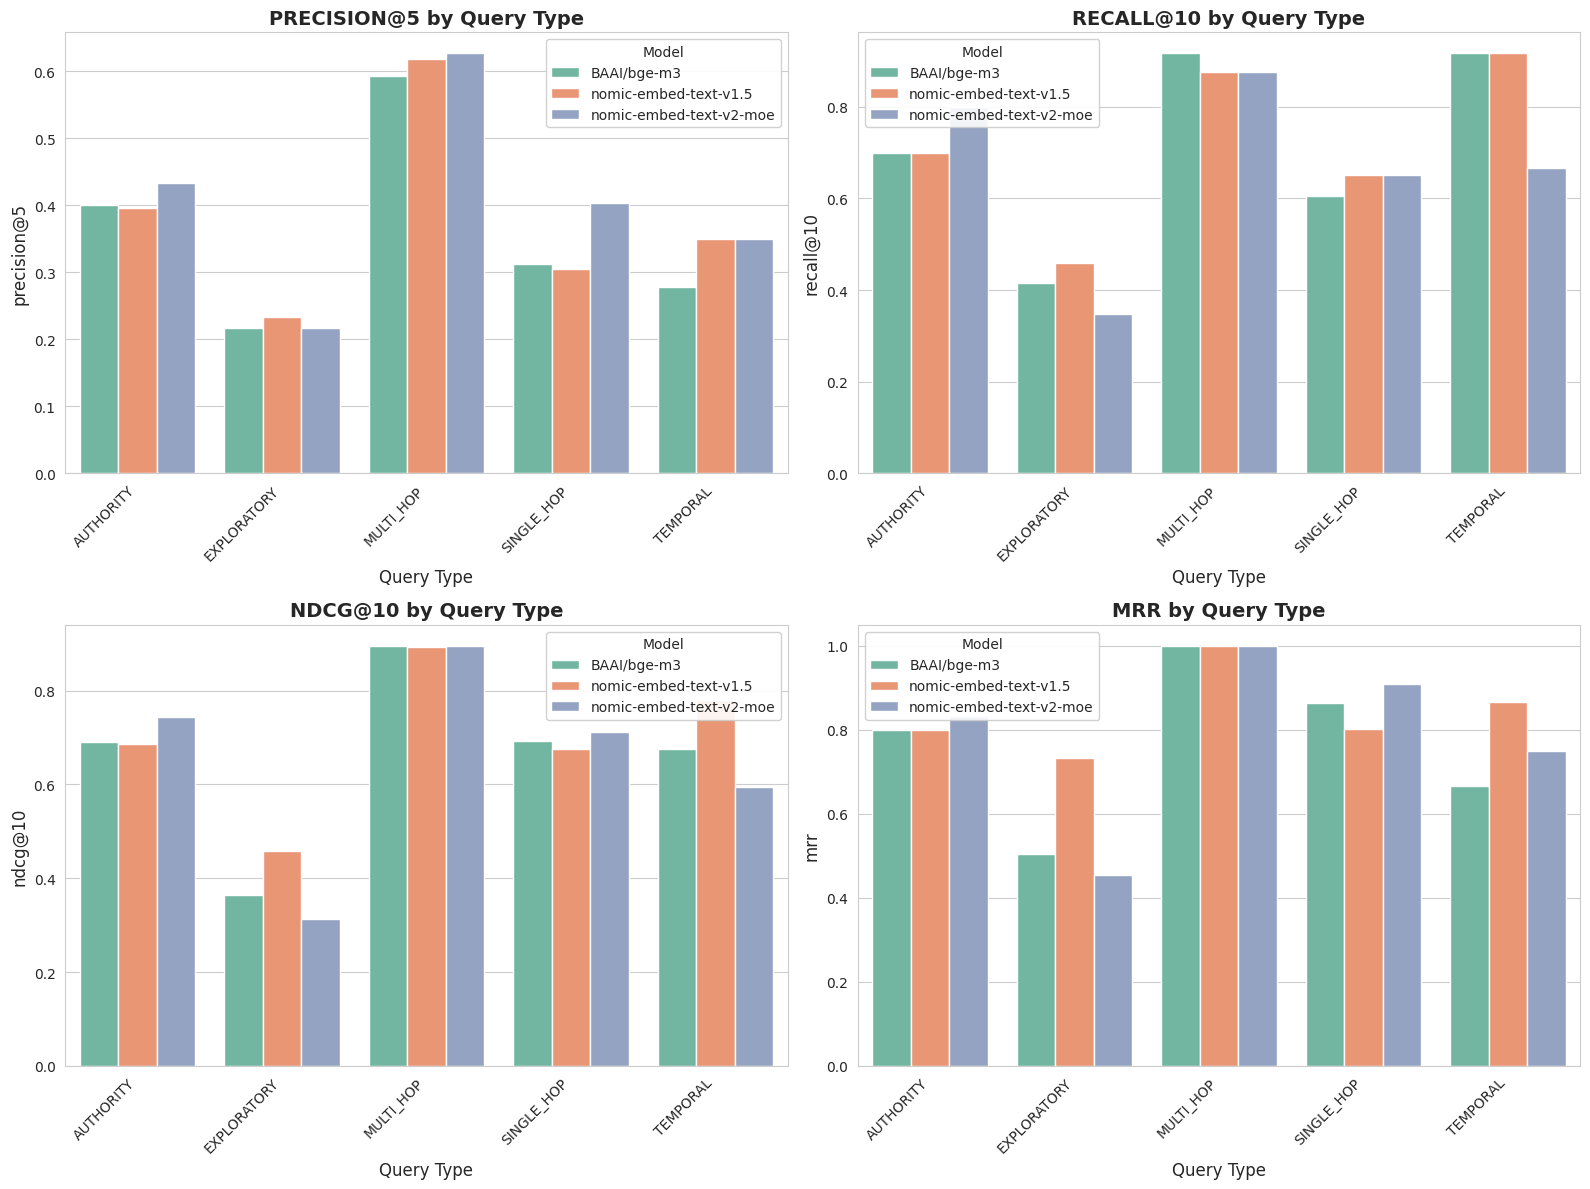

In [ ]:
"""
D-21 Baseline: Per-Query-Type Bar Charts
Visualizes metric performance stratified by query type for all models.
Reference: Conceptual Architecture §6 (query types: entity, relationship, attribute)
"""

import matplotlib.pyplot as plt
import seaborn as sns

def plot_per_query_type_metrics(results_df, output_dir):
    """
    Create a 2×2 grid of bar charts (one per metric) showing performance by
    query type, with bars grouped by model.

    Args:
        results_df: DataFrame with columns model, query_type, and metric cols
        output_dir: Path object (pathlib.Path) to save PNG output
    """
    # Configure seaborn style
    sns.set_style("whitegrid")
    sns.set_palette("Set2")

    # Create 2×2 subplot grid (one per metric)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    metrics = ["precision@5", "recall@10", "ndcg@10", "mrr"]

    for ax, metric in zip(axes.flat, metrics):
        # Group by query_type and model, compute mean
        type_data = results_df.groupby(["query_type", "model"])[metric].mean().reset_index()

        # Create bar plot with hue=model
        sns.barplot(
            data=type_data,
            x="query_type",
            y=metric,
            hue="model",
            ax=ax,
            palette="Set2"
        )

        # Styling
        ax.set_title(f"{metric.upper()} by Query Type", fontsize=14, fontweight="bold")
        ax.set_xlabel("Query Type", fontsize=12)
        ax.set_ylabel(metric, fontsize=12)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

        # Improve legend
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles, labels,
            title="Model",
            loc="best",
            framealpha=0.9
        )

    plt.tight_layout()

    # Save high-resolution PNG
    output_path = output_dir / "d21_query_type_breakdown.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"✓ Saved: {output_path}")

    plt.show()

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    from pathlib import Path

    OUTPUT_DIR = Path("d21-output")
    OUTPUT_DIR.mkdir(exist_ok=True)

    # Generate bar charts
    plot_per_query_type_metrics(results_df, OUTPUT_DIR)


✓ Saved: d21-output/d21_model_heatmap.png


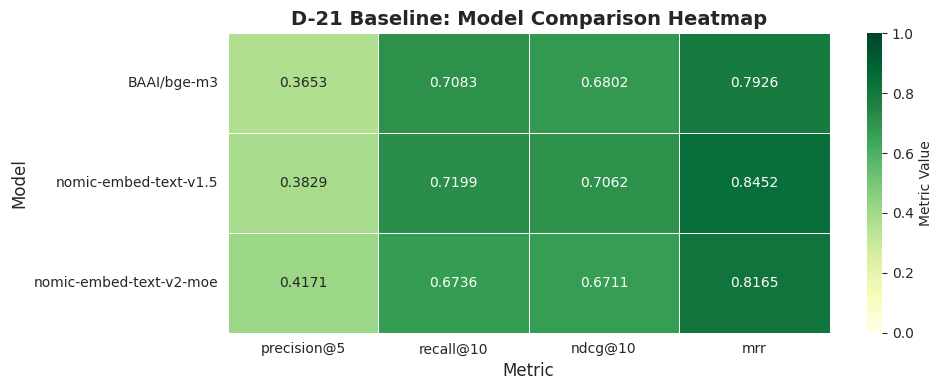


--- Best Models per Metric ---
  precision@5: nomic-embed-text-v2-moe (0.4171)
  recall@10: nomic-embed-text-v1.5 (0.7199)
  ndcg@10: nomic-embed-text-v1.5 (0.7062)
  mrr: nomic-embed-text-v1.5 (0.8452)


In [ ]:
"""
D-21 Baseline: Model Comparison Heatmap
Displays all models × all metrics in a single heatmap.
Reference: Conceptual Architecture §11 (evaluation metrics)
"""

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_model_comparison_heatmap(results_df, output_dir):
    """
    Create a heatmap showing all models × all metrics (mean values).
    The best value per column is highlighted visually by the color scale.

    Args:
        results_df: DataFrame with columns model, query_type, precision@5, recall@10, ndcg@10, mrr
        output_dir: Path object (pathlib.Path) to save PNG output
    """
    # Pivot: rows = models, columns = metrics
    metric_cols = ["precision@5", "recall@10", "ndcg@10", "mrr"]
    heatmap_data = results_df.groupby("model")[metric_cols].mean()

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 4))

    # Generate heatmap
    # cmap="YlGn" gives yellow (low) → green (high) gradient
    sns.heatmap(
        heatmap_data,
        annot=True,           # Display cell values
        fmt=".4f",            # Format to 4 decimal places
        cmap="YlGn",          # Yellow-Green colormap (low-high)
        ax=ax,
        linewidths=0.5,       # Cell borders
        cbar_kws={"label": "Metric Value"},
        vmin=0.0,             # Minimum scale value
        vmax=1.0              # Maximum scale value (all metrics are 0-1)
    )

    # Styling
    ax.set_title("D-21 Baseline: Model Comparison Heatmap", fontsize=14, fontweight="bold")
    ax.set_xlabel("Metric", fontsize=12)
    ax.set_ylabel("Model", fontsize=12)

    plt.tight_layout()

    # Save high-resolution PNG
    output_path = output_dir / "d21_model_heatmap.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"✓ Saved: {output_path}")

    plt.show()

    # Also print the best model per metric
    print("\n--- Best Models per Metric ---")
    best_models = heatmap_data.idxmax()
    best_values = heatmap_data.max()
    for metric in metric_cols:
        print(f"  {metric}: {best_models[metric]} ({best_values[metric]:.4f})")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    from pathlib import Path

    OUTPUT_DIR = Path("d21-output")
    OUTPUT_DIR.mkdir(exist_ok=True)

    # Generate heatmap
    plot_model_comparison_heatmap(results_df, OUTPUT_DIR)


Loading embeddings from ChromaDB...
  ✓ d21_baseline_v2-moe: 670 chunks
  ✓ d21_baseline_v1.5: 559 chunks
  ✓ d21_baseline_bge-m3: 559 chunks
Reducing v2-moe embeddings via UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reducing v1.5 embeddings via UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reducing bge-m3 embeddings via UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Saved: d21-output/d21_embedding_space.png


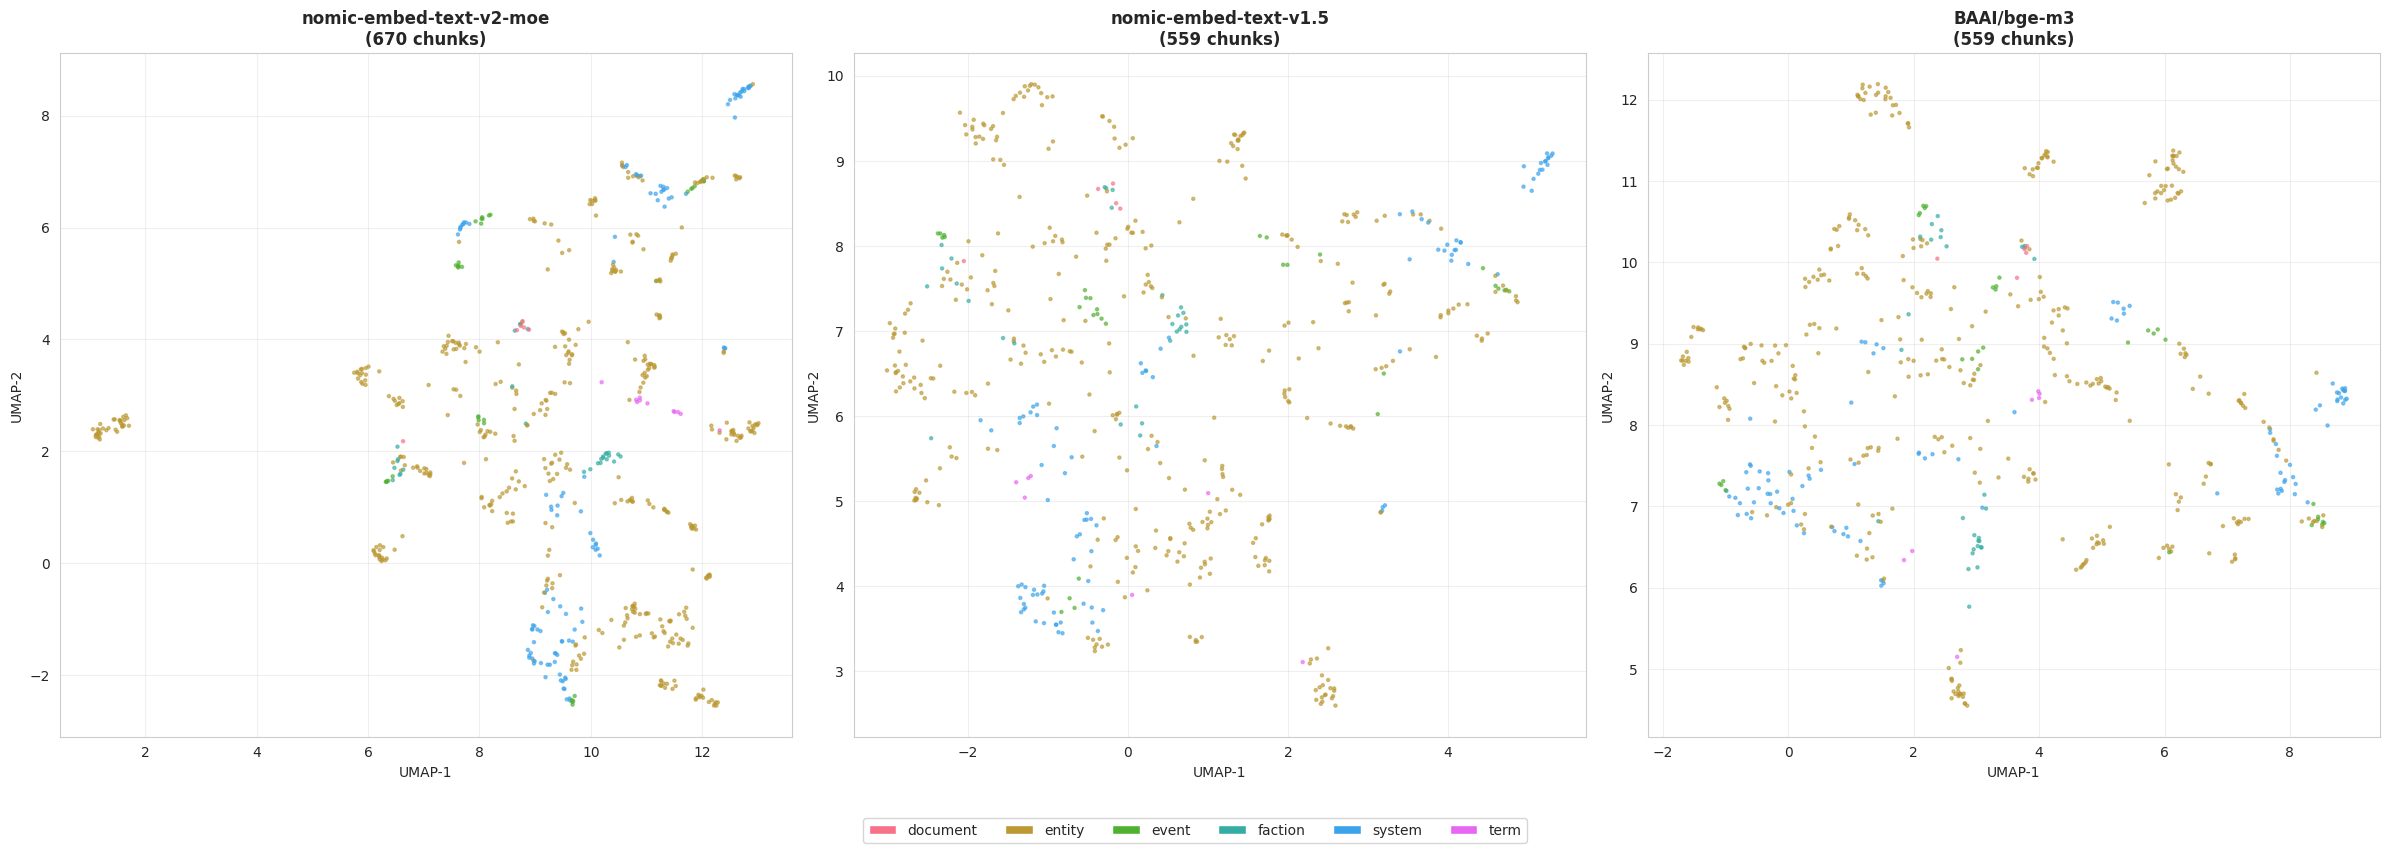

In [ ]:
"""
D-21 Baseline: Embedding Space Visualization
Projects embeddings into 2D via UMAP, colored by entity type.
Reference: Conceptual Architecture §5 (entity types in corpus)
"""

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import umap

def plot_embedding_space_by_model(chroma_client, MODELS, output_dir):
    """
    Create a 1×3 subplot grid (one per model), each showing UMAP projection of embeddings.
    Colors represent entity types.

    Args:
        chroma_client: ChromaDB client with pre-loaded collections
        MODELS: Dict[model_key, ModelConfig]
        output_dir: Path object (pathlib.Path) to save PNG output
    """
    # Collect unique entity types across all models
    all_entity_types = set()
    model_data_cache = {}

    print("Loading embeddings from ChromaDB...")
    for model_key in MODELS.keys():
        collection_name = f"d21_baseline_{model_key}"
        try:
            collection = chroma_client.get_collection(collection_name)
            all_data = collection.get(include=["embeddings", "metadatas"])

            embeddings = np.array(all_data["embeddings"])
            entity_types = [m.get("type", "unknown") for m in all_data["metadatas"]]

            model_data_cache[model_key] = (embeddings, entity_types)
            all_entity_types.update(entity_types)

            print(f"  ✓ {collection_name}: {len(embeddings)} chunks")
        except Exception as e:
            print(f"  ✗ {collection_name}: {e}")

    # Create 1×3 subplot grid
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    # Define consistent color palette for all entity types
    if not all_entity_types:
        print("  ⚠ No embedding data found in any collection. Skipping visualization.")
        return

    unique_types = sorted(all_entity_types)
    colors = sns.color_palette("husl", len(unique_types))
    type_to_color = {t: colors[i] for i, t in enumerate(unique_types)}

    # Process each model
    model_keys = list(MODELS.keys())
    for ax, model_key in zip(axes, model_keys):
        if model_key not in model_data_cache:
            ax.text(0.5, 0.5, f"No data for {model_key}", ha="center", va="center")
            continue

        embeddings, entity_types = model_data_cache[model_key]

        # Apply UMAP dimensionality reduction
        print(f"Reducing {model_key} embeddings via UMAP...")
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
        embedding_2d = reducer.fit_transform(embeddings)

        # Map entity types to colors
        point_colors = [type_to_color[t] for t in entity_types]

        # Scatter plot
        ax.scatter(
            embedding_2d[:, 0],
            embedding_2d[:, 1],
            c=point_colors,
            s=5,
            alpha=0.6
        )

        # Title and labels
        model_name = MODELS[model_key].name
        ax.set_title(
            f"{model_name}\n({len(embeddings)} chunks)",
            fontsize=12,
            fontweight="bold"
        )
        ax.set_xlabel("UMAP-1", fontsize=10)
        ax.set_ylabel("UMAP-2", fontsize=10)
        ax.grid(True, alpha=0.3)

    # Create shared legend
    from matplotlib.patches import Patch
    legend_patches = [
        Patch(facecolor=type_to_color[t], label=t)
        for t in unique_types
    ]
    fig.legend(
        handles=legend_patches,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=len(unique_types),
        fontsize=10
    )

    plt.tight_layout()

    # Save high-resolution PNG
    output_path = output_dir / "d21_embedding_space.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"✓ Saved: {output_path}")

    plt.show()

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    from pathlib import Path

    OUTPUT_DIR = Path("d21-output")
    OUTPUT_DIR.mkdir(exist_ok=True)

    # Initialize ChromaDB client (persistent or in-memory, depending on setup)
    # chroma_client is already defined in the embedding cell

    # Generate embedding space visualization
    plot_embedding_space_by_model(chroma_client, MODELS, OUTPUT_DIR)


In [ ]:
"""
D-21 Baseline: Export Results and Persist ChromaDB
Exports metrics, chunk inventory, and model summaries to CSV.
Persists ChromaDB to disk for D-22 to inherit.
Reference: Conceptual Architecture §9 (persistence layer)
"""

import pandas as pd
import json
from pathlib import Path

def export_results_to_csv(results_df, output_dir):
    """
    Export the comprehensive results DataFrame to CSV.

    Args:
        results_df: DataFrame with model, query_id, query_type, and metrics
        output_dir: Path object
    """
    output_path = output_dir / "d21_results.csv"
    results_df.to_csv(output_path, index=False)
    print(f"✓ Exported results: {output_path}")
    print(f"  Shape: {results_df.shape[0]} rows, {results_df.shape[1]} columns")

def export_chunk_inventory(chroma_client, MODELS, output_dir):
    """
    Export chunk inventory for each model: chunk_id, doc_filename, section_heading,
    token_count, embedding_model.

    Args:
        chroma_client: ChromaDB client
        MODELS: Dict[model_key, ModelConfig]
        output_dir: Path object
    """
    inventory_rows = []

    for model_key, model_config in MODELS.items():
        collection_name = f"d21_baseline_{model_key}"
        try:
            collection = chroma_client.get_collection(collection_name)
            all_data = collection.get(include=["documents", "metadatas", "ids"])

            for chunk_id, metadata in zip(all_data["ids"], all_data["metadatas"]):
                inventory_rows.append({
                    "chunk_id": chunk_id,
                    "embedding_model": model_config.name,
                    "doc_filename": metadata.get("filename", "unknown"),
                    "section_heading": metadata.get("section", "unknown"),
                    "entity_type": metadata.get("type", "unknown"),
                    "token_count": metadata.get("token_count", 0),
                })
        except Exception as e:
            print(f"  ⚠ Could not read {collection_name}: {e}")

    if inventory_rows:
        inventory_df = pd.DataFrame(inventory_rows)
        output_path = output_dir / "d21_chunk_inventory.csv"
        inventory_df.to_csv(output_path, index=False)
        print(f"✓ Exported chunk inventory: {output_path}")
        print(f"  Total chunks: {len(inventory_df)}")
    else:
        print("  ⚠ No chunk data to export")

def export_model_summary(results_df, output_dir):
    """
    Export per-model summary (mean metrics) to CSV.

    Args:
        results_df: DataFrame with results
        output_dir: Path object
    """
    metric_cols = ["precision@5", "recall@10", "ndcg@10", "mrr"]
    summary = results_df.groupby("model")[metric_cols].mean()

    output_path = output_dir / "d21_model_summary.csv"
    summary.to_csv(output_path)
    print(f"✓ Exported model summary: {output_path}")

    # Also print to console for quick review
    print("\nModel Summary (mean across all 36 queries):")
    print(summary.round(4).to_string())

def persist_chromadb(chroma_client, output_dir):
    """
    Ensure ChromaDB is persisted to disk.
    If using an EphemeralClient, data will not persist.
    If using PersistentClient, it is already persisted.

    Args:
        chroma_client: ChromaDB client instance
        output_dir: Path object
    """
    # Check client type
    client_type = type(chroma_client).__name__
    print(f"\n✓ ChromaDB client type: {client_type}")

    if "Persistent" in client_type:
        # Data already persisted to disk
        chroma_path = output_dir / "chromadb"
        print(f"  Collections persisted to: {chroma_path}")
    elif "Ephemeral" in client_type:
        # In-memory only; migration to persistent would be needed for D-22
        print("  ⚠ Ephemeral client detected (in-memory).")
        print("  → For D-22 to inherit collections, switch to PersistentClient.")

    # List all collections
    collections = chroma_client.list_collections()
    print(f"  Total collections: {len(collections)}")
    for coll in collections:
        print(f"    - {coll.name} ({coll.count()} items)")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":

    OUTPUT_DIR = Path("d21-output")
    OUTPUT_DIR.mkdir(exist_ok=True)

    # Initialize ChromaDB client
    # chroma_client is already defined in the embedding cell

    print("="*80)
    print("D-21 BASELINE: EXPORT AND PERSIST")
    print("="*80)

    # Export metrics
    export_results_to_csv(results_df, OUTPUT_DIR)

    # Export chunk inventory
    export_chunk_inventory(chroma_client, MODELS, OUTPUT_DIR)

    # Export model summary
    export_model_summary(results_df, OUTPUT_DIR)

    # Persist ChromaDB
    persist_chromadb(chroma_client, OUTPUT_DIR)

    print("\n" + "="*80)
    print("✓ All exports and persistence complete")
    print("="*80)


D-21 BASELINE: EXPORT AND PERSIST
✓ Exported results: d21-output/d21_results.csv
  Shape: 108 rows, 7 columns
  ⚠ Could not read d21_baseline_v2-moe: Expected include item to be one of documents, embeddings, metadatas, distances, uris, data, got ids in get.
  ⚠ Could not read d21_baseline_v1.5: Expected include item to be one of documents, embeddings, metadatas, distances, uris, data, got ids in get.
  ⚠ Could not read d21_baseline_bge-m3: Expected include item to be one of documents, embeddings, metadatas, distances, uris, data, got ids in get.
  ⚠ No chunk data to export
✓ Exported model summary: d21-output/d21_model_summary.csv

Model Summary (mean across all 36 queries):
                         precision@5  recall@10  ndcg@10     mrr
model                                                           
BAAI/bge-m3                   0.3653     0.7083   0.6802  0.7926
nomic-embed-text-v1.5         0.3829     0.7199   0.7062  0.8452
nomic-embed-text-v2-moe       0.4171     0.6736   0.6711

### Markdown Content

The D-21 baseline comparison directly informs the production C# implementation in Chronicle. Here are the key implications:

#### Model Selection Cascades Through the Stack

The embedding model selected as the baseline becomes a critical dependency for the entire Chronicle enrichment pipeline. A model with strong precision and NDCG scores justifies the effort to optimize C# interop; a model with marginal gains may argue for simplification.

#### Chunking Strategy Must Be Model-Aware

The token budget for each chunk (currently fixed at ~512 tokens) interacts directly with the embedding model's max_tokens limit. If the selected model is v2-moe (which has a 512-token limit), Chronicle's ingestion engine must enforce strict token budgets. If we choose v1.5 or BGE-M3 (both with larger context windows), the enrichment builder has more flexibility for prefixes and metadata.

#### ChromaDB Metadata Serialization Patterns

Our D-21 chunking stores arrays (e.g., entity types, related document IDs) as JSON strings in ChromaDB metadata. The .NET ChromaDB client library must handle the same serialization: when persisting to disk and when deserializing on retrieval, we need to parse JSON fields correctly. This is a direct translation requirement.

#### Field Mapping Layer: From Corpus to D-10 Schema

The corpus import pipeline maps raw documents → CorpusDocument → chunked segments → D-10 fields (filename, section_heading, token_count, type). Chronicle must implement an equivalent mapping in C#:


#### Token Estimation Heuristic

The D-21 code uses a crude heuristic: `token_count = word_count * 1.3`. This is a placeholder and has limitations. The production C# implementation should use the actual tokenizer for the selected model (e.g., via `TiktokenSharp` for OpenAI models, or equivalents for other architectures). This ensures accurate budget enforcement and prevents silent token overflow.

#### If v2-moe is Selected: Strict Token Budgets Required

The v2-moe model's 512-token limit is a hard constraint. Chronicle's enrichment builder must:
- Validate the token budget before calling the embedding API.
- Reject enrichment prefixes that would exceed the budget.
- Log warnings if chunks approach the limit.

This is a safety-critical requirement; failing to enforce it would result in silent truncation of enrichment context.

#### If v1.5 or BGE-M3 is Selected: More Headroom for Enrichment

These models offer 8k+ token contexts. Chronicle can afford more generous enrichment prefixes (e.g., multi-sentence summaries, richer metadata). However, the enrichment builder still needs a parameterized budget; we don't want to blindly use the full context window.

#### Performance Trade-Offs in C# Implementation

The D-21 metrics (Precision@5, Recall@10, NDCG@10, MRR) quantify the cost of different architectural choices:
- A model with high Precision@5 justifies more aggressive retrieval-phase filtering.
- A model with low Recall@10 may require retrieval amplification (e.g., larger k, multiple retrievals).
- NDCG@10 guides ranking refinement: if it's low, Chronicle should consider re-ranking in C#.


### Markdown Content

#### D-22: Notebook 2 — Single-Layer Enrichment

The next notebook (D-22) takes the baseline established here and adds a single layer of document-level context enrichment. Here's what D-22 will do:

**Consistency Requirements:**
- Use the exact same corpus and chunking as D-21 (no re-chunking, no new documents).
- Use ONLY the embedding model that won the D-21 comparison.
- Reuse the ground-truth query set (same 36 queries).

**Enrichment Strategy:**
- Add a single document-level context prefix before each chunk:
  ```
  "This is a {type} document about {name}. It is {canon_status}."
  ```
- This prefix combines metadata (entity type, document name, canonical status) without requiring an LLM.
- It replicates Anthropic's Contextual Retrieval approach but uses metadata rather than LLM-generated summaries.

**Evaluation:**
- Compute the same four metrics (Precision@5, Recall@10, NDCG@10, MRR) for each query.
- Compare directly against D-21 baseline metrics to measure the impact of single-layer enrichment.
- Expect improvement in Precision and NDCG (better ranking), possibly unchanged or slight decline in Recall (fewer documents retrieved).

**ChromaDB Inheritance:**
- D-22 starts by loading the D-21 ChromaDB collections (reference baseline performance).
- Creates new collections for the enriched chunks (e.g., `d22_enriched_v1`).
- Side-by-side comparison: D-21 vs. D-22 metrics in the same output tables and charts.

#### Context Update Before D-22 Starts

Before D-22 begins:
- Update **COLAB-SESSION-CONTEXT.md (D-32)** to document:
  - The 512-token finding (v2-moe constraint).
  - Multi-model comparison results (which model won, why).
  - Baseline metrics for future reference.
  - Lessons learned about token budgets and entity type distribution.

This ensures that future notebooks and researchers can quickly understand why certain design decisions were made.

#### Roadmap Summary

- **D-21 (current)**: Multi-model baseline comparison → establishes reference metrics.
- **D-22 (next)**: Single-layer enrichment → measures impact of metadata prefixes.
- **D-23** (planned): Multi-layer enrichment → adds chunk-level context.
- **D-27** (synthesis): Prototyping Findings Document → integrates all baseline and enrichment results.
- **Chronicle (production)**: C# implementation using insights from D-21–D-23.
